### PLATON paper: https://dl.acm.org/doi/pdf/10.1145/3626742

#### pip install numpy pandas matplotlib scikit-learn hdbscan seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
import os
from rtree import index

### 1. Creation of the synthetic datasets described in the paper

#### 1.1 Function definitions

In [3]:
def generate_uniform_dataset(n, seed):
    np.random.seed(seed)
    
    centers_x = np.random.uniform(0, 1, n)
    centers_y = np.random.uniform(0, 1, n)
    
    widths = np.random.uniform(0, 0.001, n)
    heights = np.random.uniform(0, 0.001, n)
    
    return pd.DataFrame({
        'center_x': centers_x,
        'center_y': centers_y,
        'width': widths,
        'height': heights
    })

In [4]:
def generate_skewed_dataset(n, seed):
    np.random.seed(seed)
    
    x = np.random.uniform(0, 1, n)
    y = np.random.uniform(0, 1, n)
    
    y_skewed = np.power(y, 9)
    
    return pd.DataFrame({
        'x': x,
        'y': y_skewed
    })

In [5]:
def generate_gaussian_dataset(n, seed):
    np.random.seed(seed)
    
    centers_x = np.random.normal(0, 1, n)
    centers_y = np.random.normal(0, 1, n)
    
    x_min, x_max = centers_x.min(), centers_x.max()
    y_min, y_max = centers_y.min(), centers_y.max()
    
    centers_x = (centers_x - x_min) / (x_max - x_min)
    centers_y = (centers_y - y_min) / (y_max - y_min)
    
    widths = np.random.uniform(0, 0.001, n)
    heights = np.random.uniform(0, 0.001, n)
    
    return pd.DataFrame({
        'center_x': centers_x,
        'center_y': centers_y,
        'width': widths,
        'height': heights
    })

#### 1.2 Generating the datasets

In [6]:
n_test = 1_000_000

uni_df = generate_uniform_dataset(n_test, 42)

skew_df = generate_skewed_dataset(n_test, 42)

gau_df = generate_gaussian_dataset(n_test, 42)

#### 1.3 Visualization of the datasets

In [7]:
def visualize_datasets(uni_df, skew_df, gau_df, sample_size = 30000):

    _, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Sample data for visualization if datasets are large
    uni_sample = uni_df.sample(min(sample_size, len(uni_df)))
    skew_sample = skew_df.sample(min(sample_size, len(skew_df)))
    gau_sample = gau_df.sample(min(sample_size, len(gau_df)))
    
    axes[0].scatter(uni_sample['center_x'], uni_sample['center_y'], s = 2, color='blue')
    axes[0].set_title('Uniform Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_xlim(-0.05, 1.05)
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].grid(True, alpha=0.6)
    axes[0].set_aspect('equal')
    
    axes[1].scatter(skew_sample['x'], skew_sample['y'], s = 2, color='red')
    axes[1].set_title('Skew Distribution (y^9)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_xlim(-0.05, 1.05)
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].grid(True, alpha=0.6)
    axes[1].set_aspect('equal')
    
    axes[2].scatter(gau_sample['center_x'], gau_sample['center_y'], s = 2, color='green')
    axes[2].set_title('Gaussian Distribution (Normalized)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    axes[2].set_xlim(-0.05, 1.05)
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].grid(True, alpha=0.6)
    axes[2].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

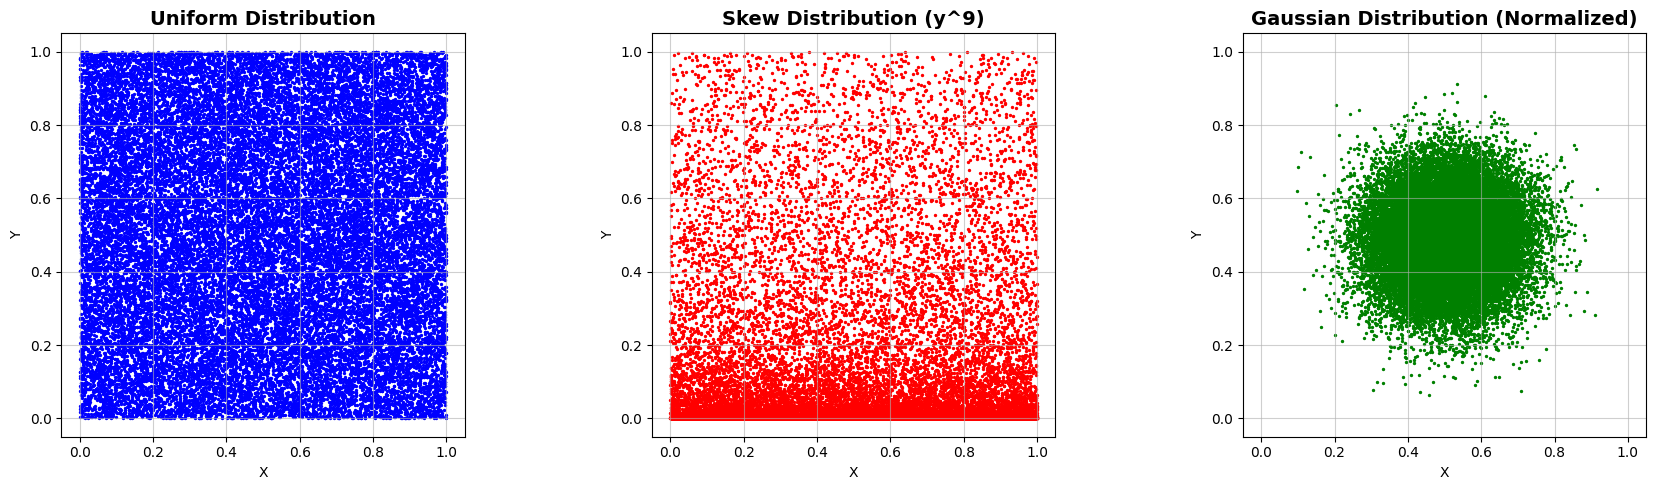

In [8]:
visualize_datasets(uni_df, skew_df, gau_df)

### 2. Generation of the workloads

#### 2.1 Function definitions

In [9]:
def generate_aspect_ratio_workload(n_queries, aspect_ratio, query_size_percent, seed):
    if seed is not None:
        np.random.seed(seed)
    
    query_area = query_size_percent / 100.0
    height = np.sqrt(query_area / aspect_ratio)
    width = aspect_ratio * height
    
    min_x = max(width / 2, 0)
    max_x = min(1.0 - width / 2, 1.0)
    min_y = max(height / 2, 0)
    max_y = min(1.0 - height / 2, 1.0)
    
    centers_x = np.random.uniform(min_x, max_x, n_queries)
    centers_y = np.random.uniform(min_y, max_y, n_queries)
    
    return pd.DataFrame({
        'center_x': centers_x,
        'center_y': centers_y,
        'width': np.full(n_queries, width),
        'height': np.full(n_queries, height)
    })

In [10]:
def generate_size_workload(n_queries, query_size_percent, seed):
    if seed is not None:
        np.random.seed(seed)
    
    query_area = query_size_percent / 100.0
    
    log_aspect_ratios = np.random.uniform(np.log(0.1), np.log(10), n_queries)
    aspect_ratios = np.exp(log_aspect_ratios)
    
    heights = np.sqrt(query_area / aspect_ratios)
    widths = aspect_ratios * heights
    
    centers_x = np.zeros(n_queries)
    centers_y = np.zeros(n_queries)
    
    for i in range(n_queries):
        min_x = max(widths[i] / 2, 0)
        max_x = min(1.0 - widths[i] / 2, 1.0)
        min_y = max(heights[i] / 2, 0)
        max_y = min(1.0 - heights[i] / 2, 1.0)
        
        centers_x[i] = np.random.uniform(min_x, max_x)
        centers_y[i] = np.random.uniform(min_y, max_y)
    
    return pd.DataFrame({
        'center_x': centers_x,
        'center_y': centers_y,
        'width': widths,
        'height': heights
    })

In [11]:
def generate_benchmark_workloads(n_queries, seed):
    workloads = {}
    
    for ar in [10, 100, 1000, 10000]:
        workloads[f'AR_{ar}'] = generate_aspect_ratio_workload(
            n_queries = n_queries,
            aspect_ratio = ar,
            query_size_percent = 0.001,
            seed = seed + ar
        )
    
    for size in [0.001, 0.005, 0.01, 0.05, 0.1]:
        workloads[f'Size_{size}%'] = generate_size_workload(
            n_queries = n_queries,
            query_size_percent = size,
            seed = seed + int(size * 10000)
        )
    
    return workloads

#### 2.2 Generation of the workloads

In [12]:
workloads = generate_benchmark_workloads(10_000, 42)

#### 2.3 Visualization of the workloads

In [13]:
def visualize_workloads(workloads, samples_per_workload):
    n_workloads = len(workloads)
    n_cols = 3
    n_rows = (n_workloads + n_cols - 1) // n_cols
    
    _ , axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    axes = axes.flatten() if n_workloads > 1 else [axes]
    
    for idx, (name, df) in enumerate(workloads.items()):
        ax = axes[idx]
        sample = df.sample(min(samples_per_workload, len(df)))
        colors = plt.cm.viridis(np.linspace(0, 1, len(sample)))
        
        for j, (_, row) in enumerate(sample.iterrows()):
            x = row['center_x'] - row['width'] / 2
            y = row['center_y'] - row['height'] / 2
            
            rect = patches.Rectangle(
                (x, y), row['width'], row['height'],
                linewidth=1, edgecolor=colors[j], 
                facecolor=colors[j], alpha=0.3
            )
            ax.add_patch(rect)
        
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(name, fontweight='bold')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

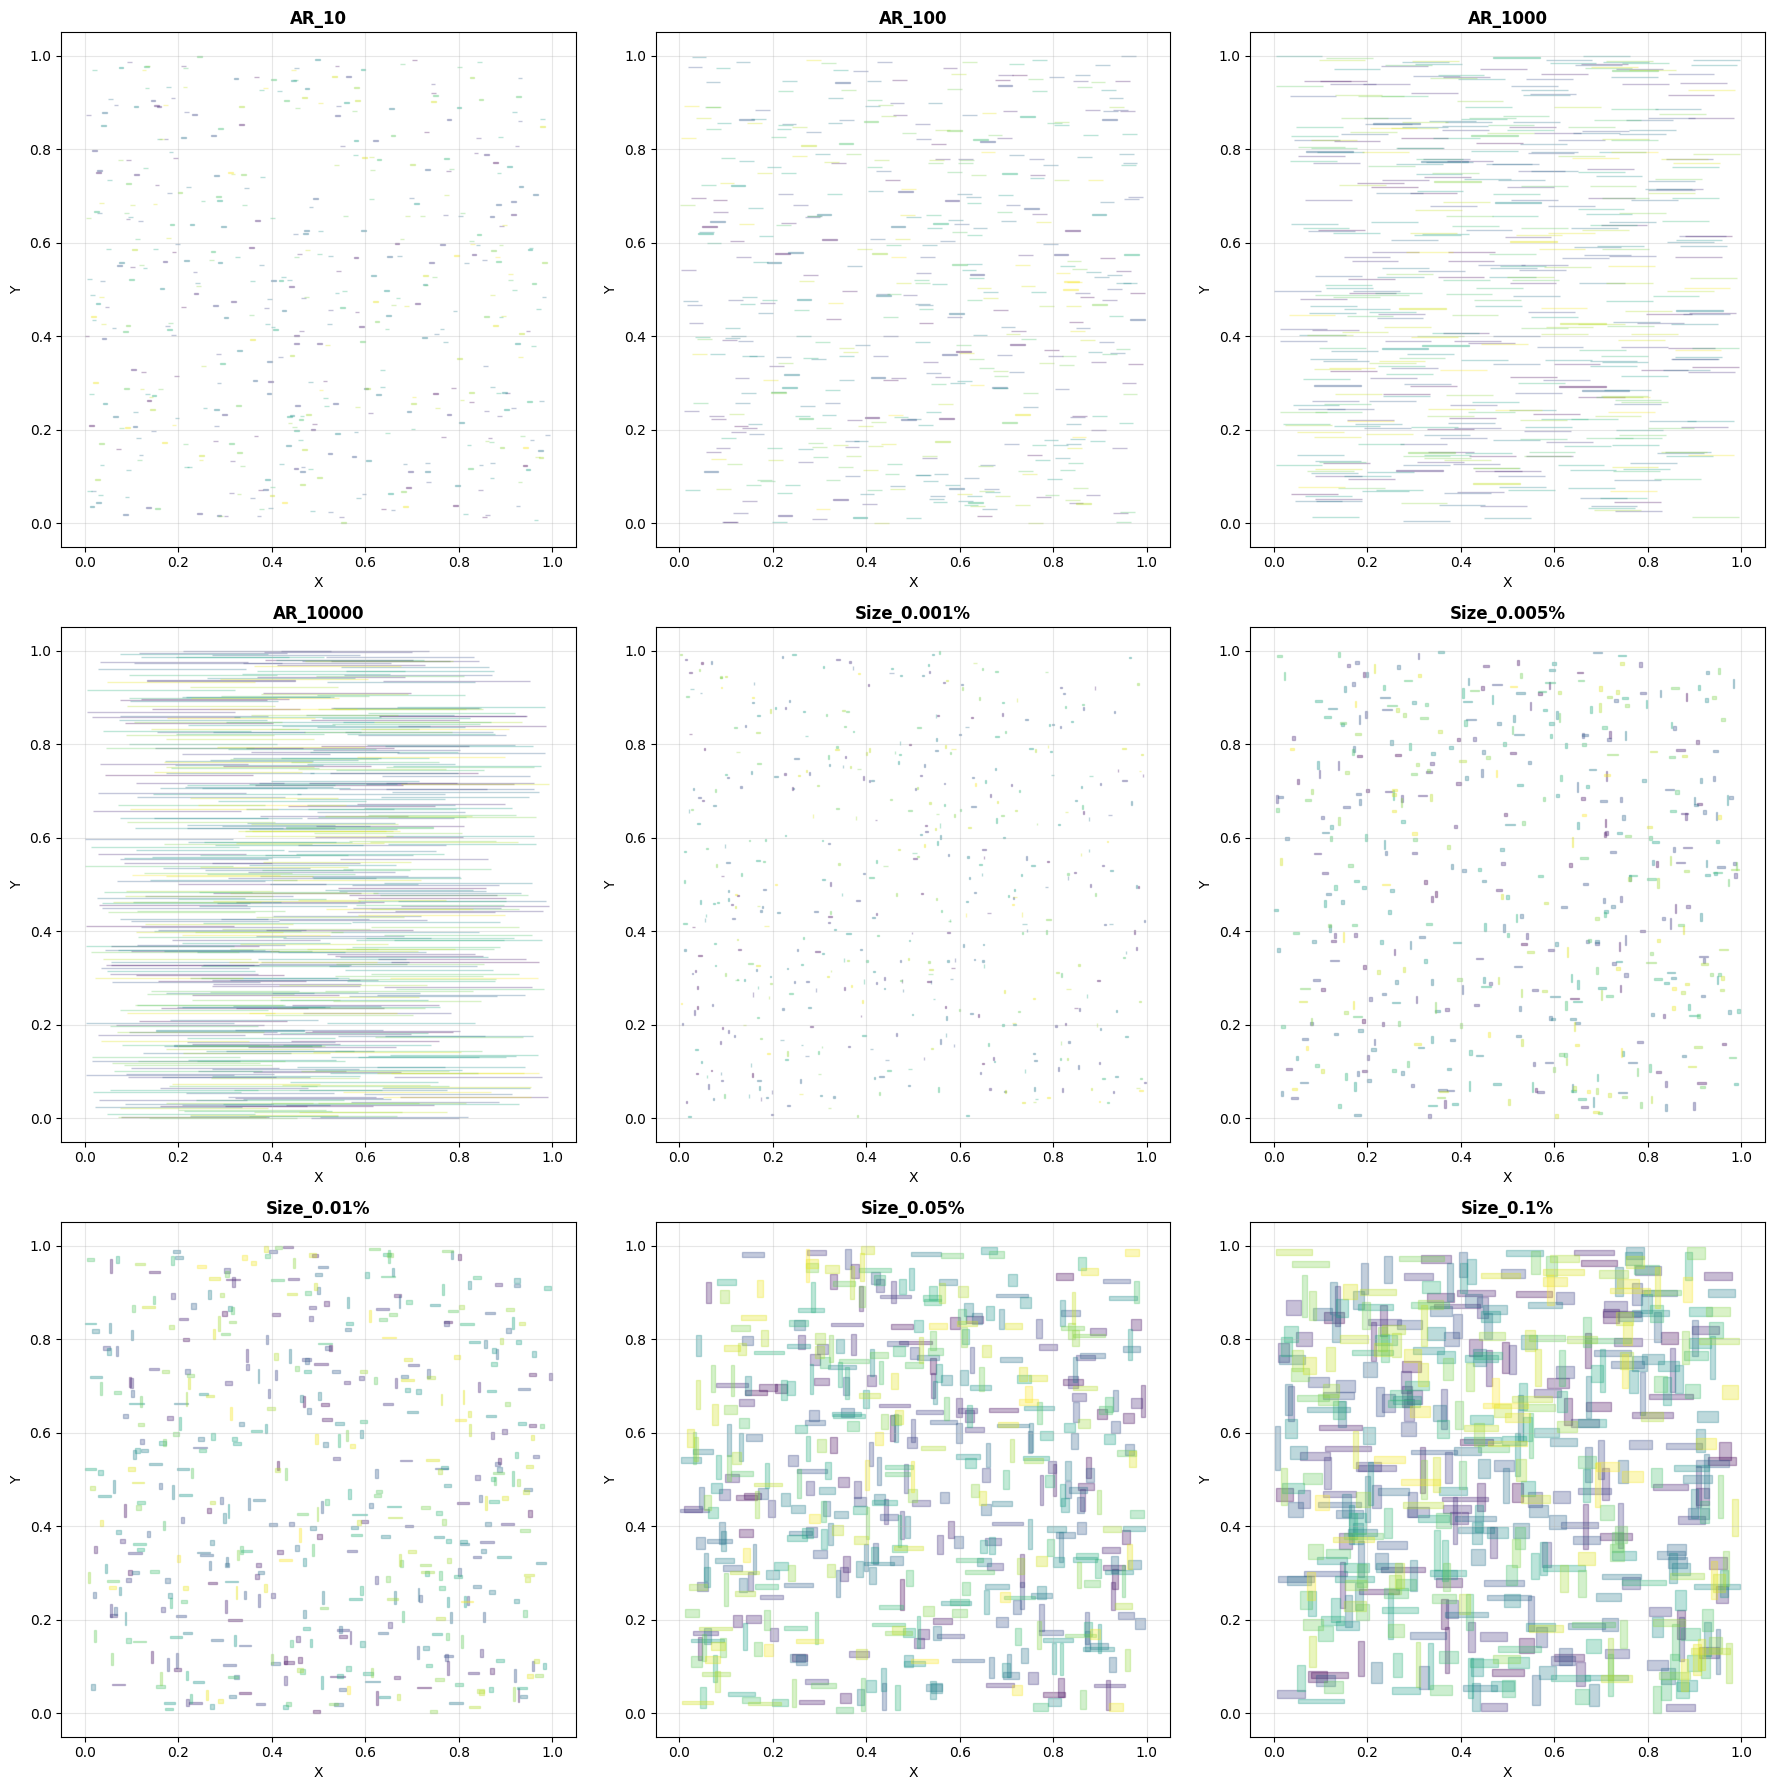

In [14]:
visualize_workloads(workloads, samples_per_workload=500)

### 3. Creation of the R-Trees

Uses: https://rtree.readthedocs.io/en/stable/

##### 3.1 Function definitions

In [15]:
# page size and capacity per the PLATON paper
Page_Size = 4096
Record_Size = 36
Capacity = Page_Size // Record_Size   # 113
fill_factor = 0.7 # not specified in the paper

In [16]:
def build_rtree(records, path, bulk):
    p = index.Property()
    p.dimension = 2
    p.pagesize = Page_Size
    p.leaf_capacity = Capacity
    p.index_capacity = Capacity
    p.fill_factor = fill_factor

    if bulk:
        if path is None:
            p.storage = index.RT_Memory
            return index.Index(records, properties=p)
        else:
            p.storage = index.RT_Disk
            return index.Index(path, records, properties=p)

    if path is None:
        p.storage = index.RT_Memory
    else:
        p.storage = index.RT_Disk
        
    idx = index.Index(path, properties=p)
    
    for rid, bounds, obj in records:
        idx.insert(rid, bounds, obj)
        
    return idx

In [17]:
def build_rtree_with_stats(records, path, bulk, label="dataset"):
    t0 = time.perf_counter()
    idx = build_rtree(records, path, bulk)
    t1 = time.perf_counter()
    
    s = idx.get_statistics()
    
    stats_data = {
        "dataset": label,
        "method": "str_bulk" if bulk else "iterative",
        "storage": "disk" if path else "memory",
        "build_time_s": t1 - t0,
        "reads": s['reads'],
        "writes": s['writes'],
        "nodes": s['nodes'],
        "splits": s['splits'],
        "adjustments": s['adjustments'],
        "height": s['tree_height'],
        "nodes_per_level": s['nodes_per_level']
    }
    
    return idx, stats_data

In [18]:
def df_to_mbr_generator(df):
    if all(col in df.columns for col in ['center_x', 'center_y', 'width', 'height']):
        # Rectangle data
        x_col, y_col = 'center_x', 'center_y'
        for i, row in df.iterrows():
            half_w = row['width'] / 2
            half_h = row['height'] / 2
            yield i, (
                row[x_col] - half_w,
                row[y_col] - half_h,
                row[x_col] + half_w,
                row[y_col] + half_h
            ), None
    elif all(col in df.columns for col in ['x', 'y']):
        # Point data
        x_col, y_col = 'x', 'y'
        for i, row in df.iterrows():
            yield i, (row[x_col], row[y_col], row[x_col], row[y_col]), None
    else:
        raise ValueError("Unknown column format.Expected either ['x','y'] or ['center_x','center_y','width','height']")

In [19]:
def tree_exists(name, suffix):
    base_path = f"{name}_{suffix}"
    return os.path.exists(f"{base_path}.dat") and os.path.exists(f"{base_path}.idx")

In [20]:
def create_all_rtrees(datasets, configs):
    all_results = []
    active_trees = {}
    
    for name, df in datasets.items():
        for cfg in configs:
            path = f"{name}_{cfg['suffix']}" if cfg['disk'] else None
            
            # Check if disk tree already exists
            if cfg['disk'] and tree_exists(name, cfg['suffix']):
                
                idx = index.Index(path)
                s = idx.get_statistics()
                
                stats_data = {
                    "dataset": name,
                    "method": "str_bulk" if cfg['bulk'] else "iterative",
                    "storage": "disk",
                    "build_time_s": None,  # Not tracked for existing disk trees
                    "reads": s['reads'],
                    "writes": s['writes'],
                    "nodes": s['nodes'],
                    "splits": s['splits'],
                    "adjustments": s['adjustments'],
                    "height": s['tree_height'],
                    "nodes_per_level": s['nodes_per_level']
                }

                stats_data['full_method'] = f"{stats_data['method']}_{stats_data['storage']}"
                all_results.append(stats_data)
                
                idx.close()
                continue
            
            idx, stats = build_rtree_with_stats(
                df_to_mbr_generator(df), 
                path, 
                cfg['bulk'], 
                label=name
            )

            stats['full_method'] = f"{stats['method']}_{stats['storage']}"
            all_results.append(stats)
            
            if cfg['disk']:
                idx.close()  # Close disk trees
            else:
                active_trees[f"{name}_{cfg['suffix']}"] = idx  # Keep memory trees alive
    
    df_results = pd.DataFrame(all_results)

    return df_results, active_trees

In [21]:
def reload_disk_trees(df):
    disk_trees = {}
    
    for _, row in df[df['storage'] == 'disk'].iterrows():
        name = row['dataset']
        method = row['method']
        path = f"{name}_{method}_disk"
        tree_key = f"{name}_{method}_disk"
        disk_trees[tree_key] = index.Index(path)
    
    return disk_trees

#### 3.2 Building of the R-Trees

In [22]:
datasets = {
    "UNI": uni_df,
    "SKEW": skew_df,
    "GAU": gau_df
}

In [23]:
configs = [
    {"bulk": True,  "disk": False, "suffix": "str_bulk_memory"},
    {"bulk": False, "disk": False, "suffix": "iterative_memory"},
]

In [25]:
df_tree_stats, active_trees = create_all_rtrees(datasets, configs)

In [26]:
df_tree_stats

,dataset,method,storage,build_time_s,reads,writes,nodes,splits,adjustments,height,nodes_per_level,full_method
0,UNI,str_bulk,memory,23.561213,1,12825,12824,0,0,4,"[12659, 161, 3, 1]",str_bulk_memory
1,UNI,iterative,memory,65.982236,7109424,2585026,12390,12386,526524,4,"[12247, 140, 2, 1]",iterative_memory
2,SKEW,str_bulk,memory,20.429759,1,12825,12824,0,0,4,"[12659, 161, 3, 1]",str_bulk_memory
3,SKEW,iterative,memory,61.486581,7005711,2714851,12403,12399,766224,4,"[12252, 148, 2, 1]",iterative_memory
4,GAU,str_bulk,memory,23.658051,1,12825,12824,0,0,4,"[12659, 161, 3, 1]",str_bulk_memory
5,GAU,iterative,memory,65.686989,7124797,2565193,12116,12112,482553,4,"[11970, 143, 2, 1]",iterative_memory


#### 3.3 Visualizations

In [27]:
def plot_rtree_build_analysis(df_results, total_points):
    _, axes = plt.subplots(3, 2, figsize=(16, 18))
    axes = axes.flatten()
    
    datasets = sorted(df_results['dataset'].unique())
    methods = sorted(df_results['full_method'].unique())
    
    x = np.arange(len(datasets))
    width = 0.5 / len(methods)

    target_per_leaf = Capacity * fill_factor
    min_number_leaf_nodes = np.ceil(total_points / target_per_leaf)
    
    df_results['leaf_nodes'] = df_results['nodes_per_level'].apply(lambda x: x[0])
    df_results['fill_ratio'] = (min_number_leaf_nodes / df_results['leaf_nodes']) * 100.0
    
    metrics_to_plot = [
        (['build_time_s'], 'Build Time (Seconds)', False),
        (['reads', 'writes'], 'Total I/O Operations (Log)', True),
        (['splits', 'adjustments'], 'Splits/Adjustments)', False),
        (['nodes'], 'Total Node Count', False),
        (['height'], 'Tree Height', False),
        (['fill_ratio'], 'Fill Ratio (%)', False)
    ]
    
    for i, (cols, title, use_log) in enumerate(metrics_to_plot):
        ax = axes[i]
        for j, method in enumerate(methods):
            data = df_results[df_results['full_method'] == method].sort_values('dataset')
            values = data[cols].sum(axis=1)
            
            offset = width * (j - len(methods)/2 + 0.5)
            ax.bar(x + offset, values, width, label=method)
        
        ax.set_title(title, fontweight='bold')
        if use_log: 
            ax.set_yscale('log')
        if 'Fill Ratio (%)' in title:
            ax.set_ylim(0, 100)
            
        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.grid(axis='y', alpha=0.3)
        
        if i == 0:
            ax.legend(loc='upper left', bbox_to_anchor=(0, 1.2), ncol=2)
    
    plt.tight_layout()
    plt.show()

In [28]:
def plot_nodes_per_level(df_results):
    max_h = int(df_results['height'].max())
    levels_to_plot = max_h - 1 
    
    _, axes = plt.subplots(levels_to_plot, 1, figsize=(16, 4 * levels_to_plot))

    if levels_to_plot == 1:
        axes = [axes]
    
    datasets = sorted(df_results['dataset'].unique())
    methods = sorted(df_results['full_method'].unique())
    
    x = np.arange(len(datasets))
    width = 0.5 / len(methods)
    
    for level_idx in range(levels_to_plot):
        ax = axes[level_idx]
        for i, method in enumerate(methods):
            method_data = df_results[df_results['full_method'] == method].sort_values('dataset')
            counts = []
            for val in method_data['nodes_per_level']:
                if level_idx < len(val):
                    counts.append(val[level_idx])
                else:
                    counts.append(0)
            
            offset = width * (i - len(methods)/2 + 0.5)
            ax.bar(x + offset, counts, width, label=method if level_idx == 0 else "")
        
        ax.set_title(f'Node Count at Level {level_idx} {"(Leaf Level)" if level_idx == 0 else ""}', fontweight='bold')
        ax.set_ylabel('Nodes')
        ax.grid(axis='y', alpha=0.3)
    
    for ax in axes:
        ax.set_xticks(x) 
        ax.set_xticklabels(datasets)
    
    axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

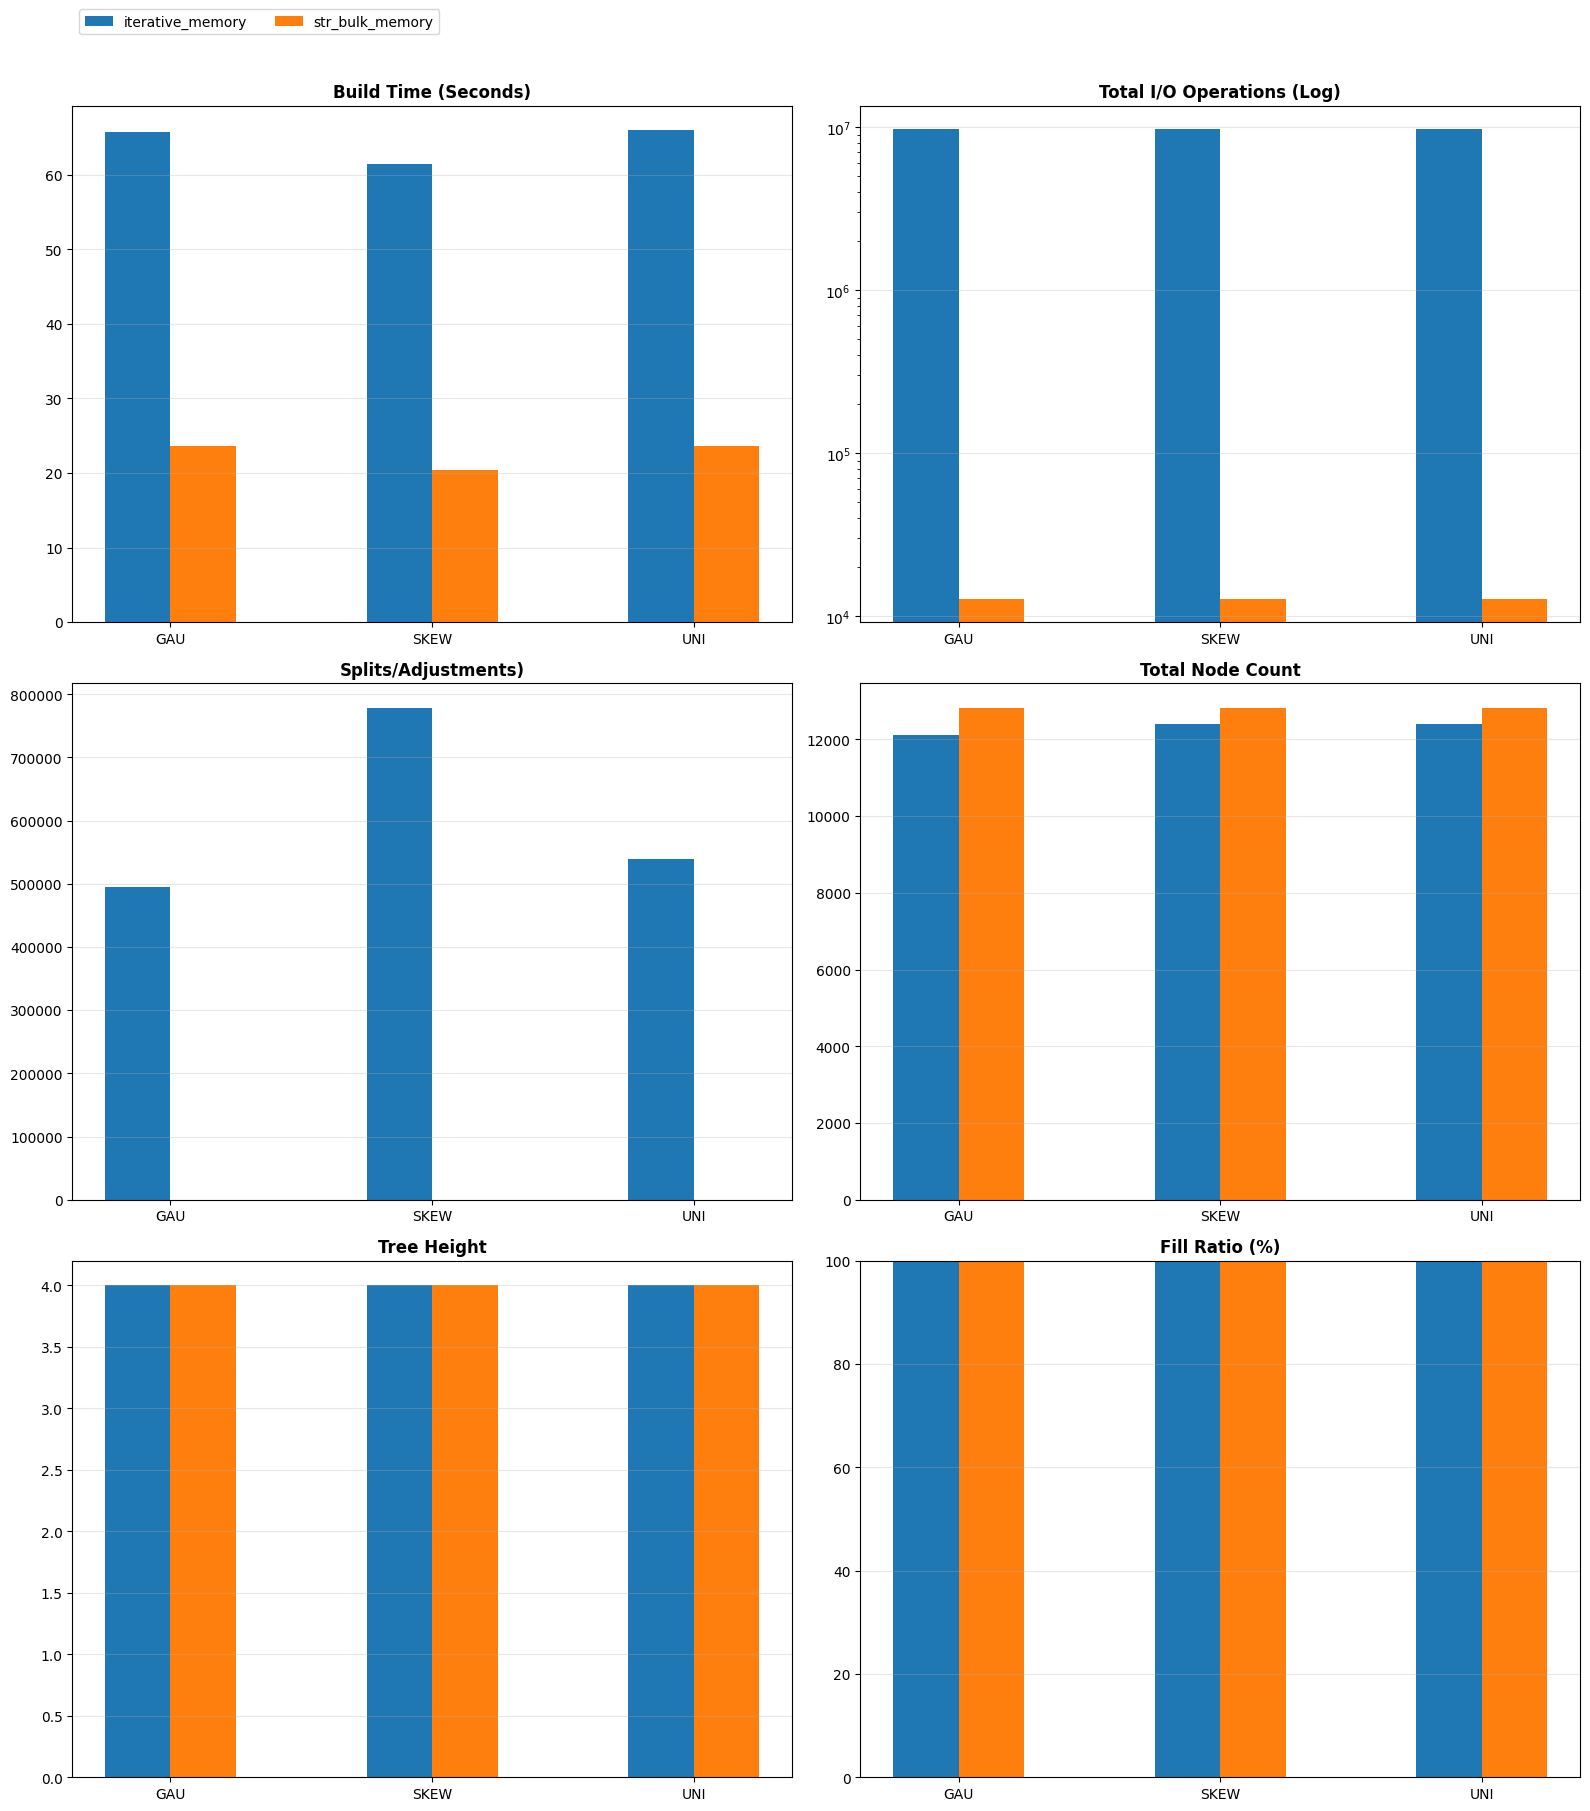

In [29]:
plot_rtree_build_analysis(df_tree_stats, n_test)

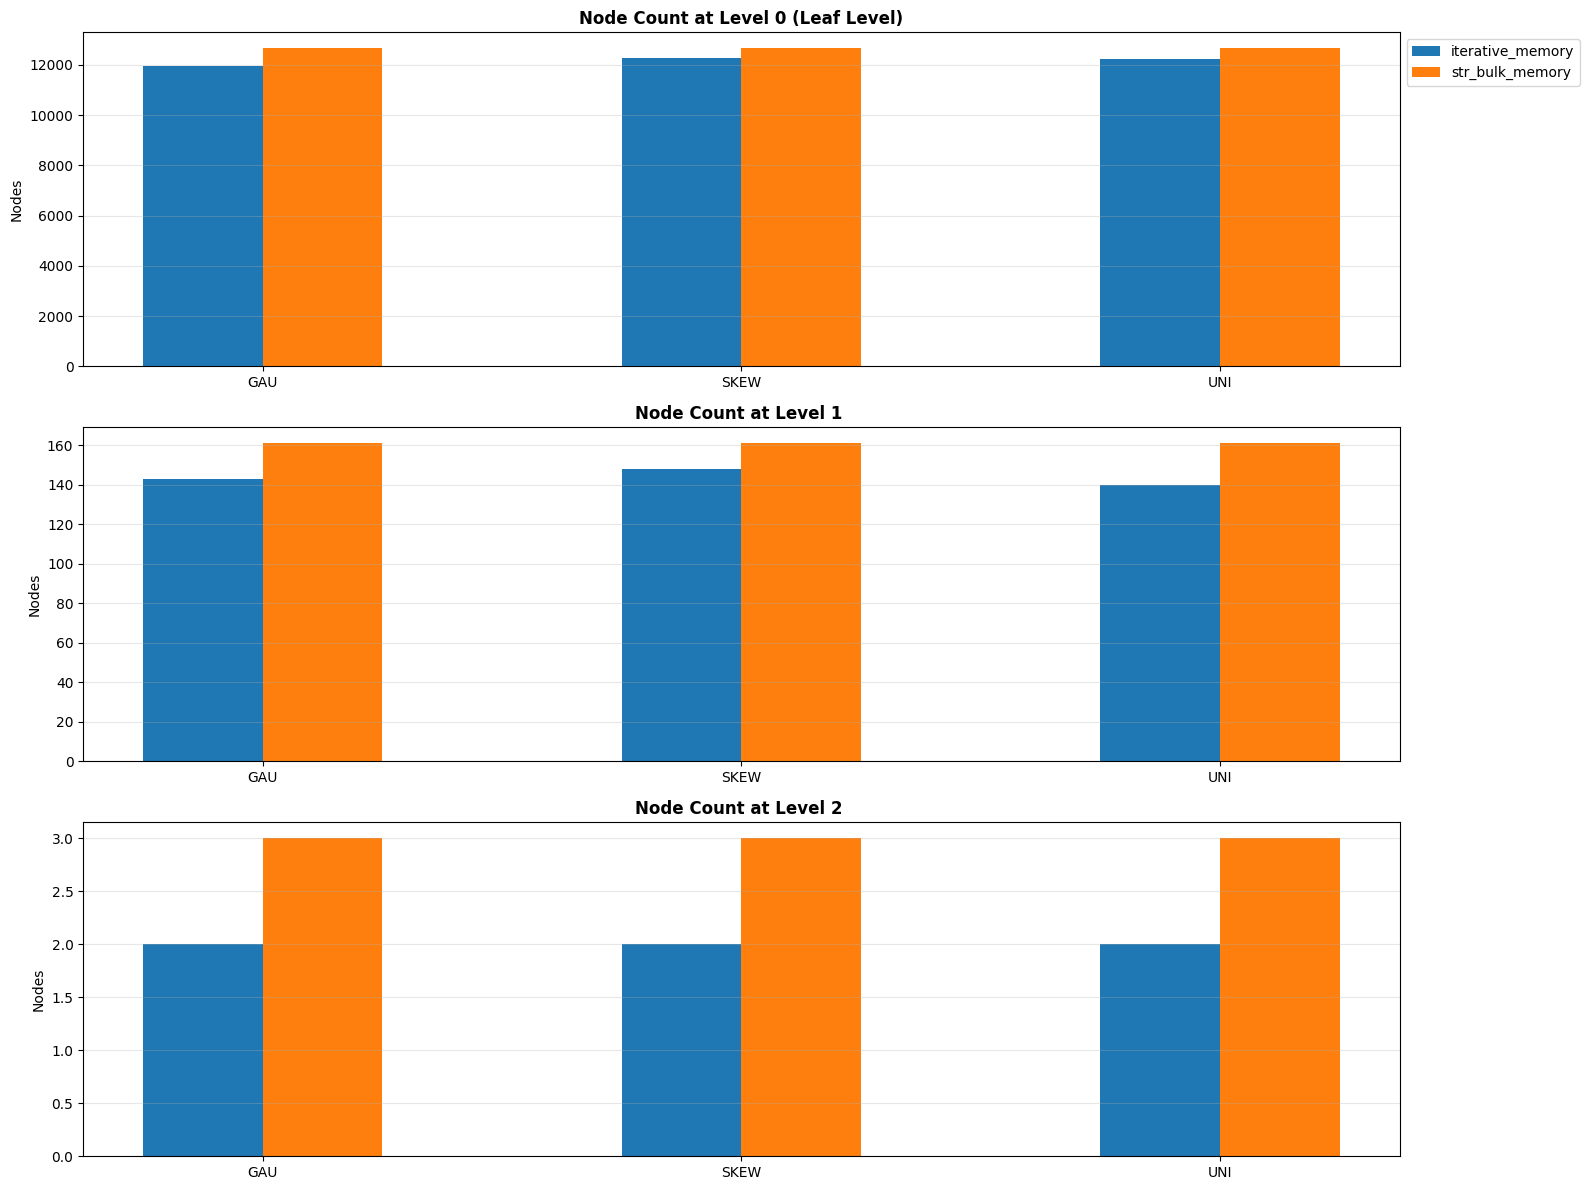

In [30]:
plot_nodes_per_level(df_tree_stats)

### 4. Benchmarks

#### 4.1 Function definitions

In [31]:
def workload_to_mbr(df):    
    # Rectangles
    if "width" in df.columns and "height" in df.columns:
        half_w = df["width"] / 2
        half_h = df["height"] / 2

        minx = df["center_x"] - half_w
        maxx = df["center_x"] + half_w
        miny = df["center_y"] - half_h
        maxy = df["center_y"] + half_h

        return list(zip(minx, miny, maxx, maxy))

    # Points
    else:
        return list(zip(df["x"], df["y"], df["x"], df["y"]))

In [32]:
def benchmark_workload(idx, workload_mbrs):
    stats_before = idx.get_statistics()
    
    latencies = []
    
    for mbr in workload_mbrs:
        t0 = time.perf_counter()
        idx.intersection(mbr, objects=False)
        t1 = time.perf_counter()
        latencies.append((t1 - t0) * 1e6)  # microseconds
    
    stats_after = idx.get_statistics()
    
    stats_delta = {
        'query_results': stats_after['query_results'] - stats_before['query_results'],
        'reads': stats_after['reads'] - stats_before['reads'],
    }
    
    latency_df = pd.DataFrame({
        "latency_us": latencies,
    })
    
    return latency_df, stats_delta

In [33]:
def benching(tree, workload):
    if not isinstance(tree, dict):
        tree = {"tree": tree}
        
    results = []
    stats_results = []
    
    for dataset_name, idx in tree.items():
        for workload_name, df in workload.items():
            workload_mbrs = workload_to_mbr(df)
            
            df_result, stats_delta = benchmark_workload(idx, workload_mbrs)
            df_result["dataset"] = dataset_name
            df_result["workload"] = workload_name
            results.append(df_result)
            
            stats_delta.update({
                "dataset": dataset_name,
                "workload": workload_name,
            })
            stats_results.append(stats_delta)
    
    final_results = pd.concat(results, ignore_index=True)
    final_stats = pd.DataFrame(stats_results)
    
    return final_results, final_stats

In [34]:
def summarize_benchmark_single(result_df, stats_df, precision=4):
    timing_summary = result_df.groupby(["dataset", "workload"]).agg(
        avg_latency_us=('latency_us', 'mean'),
        p50_latency_us=('latency_us', lambda x: np.percentile(x, 50)),
        p95_latency_us=('latency_us', lambda x: np.percentile(x, 95)),
        p99_latency_us=('latency_us', lambda x: np.percentile(x, 99)),
        min_latency_us=('latency_us', 'min'),
        max_latency_us=('latency_us', 'max')
    ).reset_index()
    
    summary = timing_summary.merge(
        stats_df,
        on=["dataset", "workload"],
        how="left"
    )
    
    summary['reads_per_query'] = summary['reads'] / 10000
    summary['results_per_read'] = summary['query_results'] / summary['reads'].replace(0, np.nan)
    
    latency_cols = ['avg_latency_us','p50_latency_us', 'p95_latency_us', 'p99_latency_us', 'min_latency_us', 'max_latency_us']
    summary[latency_cols] = summary[latency_cols].round(precision)
    
    ratio_cols = ['reads_per_query', 'results_per_read']
    summary[ratio_cols] = summary[ratio_cols].round(2)
    
    int_cols = ['query_results', 'reads', 'hits', 'misses']
    for col in int_cols:
        if col in summary.columns:
            summary[col] = summary[col].fillna(0).round(0).astype(int)
    
    return summary

In [35]:
def benching_multi_run(tree, workload, n_runs):
    """
    Runs the benchmarks multiple times.
    
    Args:
        tree: Dict of {dataset_name: index} or single index
        workload: Dict of {workload_name: dataframe}
        n_runs: Number of benchmark runs (default: 3)
    """
    if not isinstance(tree, dict):
        tree = {"tree": tree}
    
    all_runs_results = []
    all_runs_stats = []
    
    for run_idx in range(n_runs):
        result_df, stats_df = benching(tree, workload)
        
        result_df['run'] = run_idx
        stats_df['run'] = run_idx
        
        all_runs_results.append(result_df)
        all_runs_stats.append(stats_df)
    
    combined_results = pd.concat(all_runs_results, ignore_index=True)
    combined_stats = pd.concat(all_runs_stats, ignore_index=True)
    
    return combined_results, combined_stats

In [36]:
def summarize_benchmark_multi(result_df, stats_df, method):
    """
    Aggregates the benchmark results across multiple runs and summarizes them.
    
    Args:
        result_df: Combined results from all runs with 'run' column
        stats_df: Combined stats from all runs with 'run' column
        method: 'median' or 'mean'
    
    Returns:
        Aggregated summary dataframe
    """
    agg_func = np.median if method == 'median' else np.mean
    
    timing_summary = result_df.groupby(["dataset", "workload"]).agg(
        avg_latency_us=('latency_us', lambda x: agg_func(x)),
        p50_latency_us=('latency_us', lambda x: agg_func(np.percentile(x, 50))),
        p95_latency_us=('latency_us', lambda x: agg_func(np.percentile(x, 95))),
        p99_latency_us=('latency_us', lambda x: agg_func(np.percentile(x, 99))),
        min_latency_us=('latency_us', 'min'), 
        max_latency_us=('latency_us', 'max')
    ).reset_index()
    
    # Aggregate stats (reads, query_results, etc.)
    stats_summary = stats_df.groupby(["dataset", "workload"]).agg({
        'query_results': agg_func,
        'reads': agg_func
    }).reset_index()
    
    summary = timing_summary.merge(
        stats_summary,
        on=["dataset", "workload"],
        how="left"
    )
    
    summary['reads_per_query'] = summary['reads'] / 10000
    summary['results_per_read'] = summary['query_results'] / summary['reads'].replace(0, np.nan)
    
    latency_cols = ['avg_latency_us', 'p50_latency_us', 'p95_latency_us', 'p99_latency_us', 'min_latency_us', 'max_latency_us']
    summary[latency_cols] = summary[latency_cols].round(4)
    
    ratio_cols = ['reads_per_query', 'results_per_read']
    summary[ratio_cols] = summary[ratio_cols].round(2)
    
    int_cols = ['query_results', 'reads']
    for col in int_cols:
        if col in summary.columns:
            summary[col] = summary[col].fillna(0).round(0).astype(int)
    
    return summary

#### 4.2 Results

In [37]:
memory_result_df, memory_stats_df = benching(active_trees, workloads)

In [38]:
summary_memory = summarize_benchmark_single(memory_result_df, memory_stats_df, precision=4)
summary_memory

,dataset,workload,avg_latency_us,p50_latency_us,p95_latency_us,p99_latency_us,min_latency_us,max_latency_us,query_results,reads,reads_per_query,results_per_read
0,GAU_iterative_memory,AR_10,14.5144,11.0300,38.2016,57.2149,2.910,117.205,161125,49447,4.94,3.26
1,GAU_iterative_memory,AR_100,20.5984,12.9955,67.6335,105.0862,2.980,156.598,266334,67438,6.74,3.95
2,GAU_iterative_memory,AR_1000,44.3870,20.7960,179.0890,261.3497,4.600,368.338,686839,133618,13.36,5.14
3,GAU_iterative_memory,AR_10000,133.3751,63.8130,473.8155,632.3079,5.120,1017.249,2379589,398590,39.86,5.97
4,GAU_iterative_memory,Size_0.001%,13.0657,10.5310,30.9515,46.6334,2.860,75.523,139149,46398,4.64,3.00
5,GAU_iterative_memory,Size_0.005%,18.5065,11.7110,61.2745,99.4957,2.941,154.327,578740,59657,5.97,9.70
6,GAU_iterative_memory,Size_0.01%,24.8865,13.1200,96.9880,162.1785,2.870,238.571,1154705,72638,7.26,15.90
7,GAU_iterative_memory,Size_0.05%,60.7419,16.6610,334.0670,549.8282,2.960,825.920,5627544,152387,15.24,36.93
8,GAU_iterative_memory,Size_0.1%,102.2339,20.3310,582.9055,986.3879,3.020,1313.273,11194251,240170,24.02,46.61
9,GAU_str_bulk_memory,AR_10,13.9875,10.9810,32.7630,44.8526,2.870,129.736,161125,52194,5.22,3.09


In [39]:
memory_multi_result_df, memory_multi_stats_df = benching_multi_run(active_trees, workloads, n_runs = 10)

In [40]:
summary_memory_multi = summarize_benchmark_multi(memory_multi_result_df, memory_multi_stats_df, method='mean')
summary_memory_multi

,dataset,workload,avg_latency_us,p50_latency_us,p95_latency_us,p99_latency_us,min_latency_us,max_latency_us,query_results,reads,reads_per_query,results_per_read
0,GAU_iterative_memory,AR_10,14.6098,11.1400,37.8620,57.0231,2.860,175.328,161125,49447,4.94,3.26
1,GAU_iterative_memory,AR_100,21.2005,13.3610,69.5930,108.0752,2.940,238.382,266334,67438,6.74,3.95
2,GAU_iterative_memory,AR_1000,44.3526,20.8110,179.3590,261.0534,4.510,671.411,686839,133618,13.36,5.14
3,GAU_iterative_memory,AR_10000,134.6015,64.4230,478.8035,634.9690,4.890,1111.393,2379589,398590,39.86,5.97
4,GAU_iterative_memory,Size_0.001%,13.5007,10.8300,32.0315,48.7120,2.810,169.708,139149,46398,4.64,3.00
5,GAU_iterative_memory,Size_0.005%,19.0310,11.9710,63.1721,103.0751,2.830,289.354,578740,59657,5.97,9.70
6,GAU_iterative_memory,Size_0.01%,25.0605,13.1210,98.2845,164.3081,2.850,451.851,1154705,72638,7.26,15.90
7,GAU_iterative_memory,Size_0.05%,62.1179,16.8310,339.8851,568.9365,2.880,953.634,5627544,152387,15.24,36.93
8,GAU_iterative_memory,Size_0.1%,103.7084,20.2510,598.5729,1027.7072,2.890,1975.371,11194251,240170,24.02,46.61
9,GAU_str_bulk_memory,AR_10,13.8029,10.8210,32.2910,43.6231,2.860,142.357,161125,52194,5.22,3.09


#### 4.3 Visualizations

In [41]:
def plot_comparison_multiplot(results_dict, metric, figsize=(18, 5)):
    all_prefixes = set()
    for df in results_dict.values():
        for dataset in df['dataset'].unique():
            prefix = dataset.split('_')[0].lower()
            all_prefixes.add(prefix)
    
    prefixes = sorted(all_prefixes)
    
    fig, axes = plt.subplots(1, len(prefixes), figsize=figsize, sharey=True)
    
    if len(prefixes) == 1:
        axes = [axes]
    
    for ax_idx, prefix in enumerate(prefixes):
        ax = axes[ax_idx]
        
        first_df = list(results_dict.values())[0]
        matching_datasets = [d for d in first_df['dataset'].unique() 
                            if d.split('_')[0].lower() == prefix]
        
        if not matching_datasets:
            continue
            
        dataset_data = first_df[first_df['dataset'] == matching_datasets[0]]
        workloads = dataset_data['workload'].values
        x = np.arange(len(workloads))
        width = 0.8 / len(results_dict)
        
        for config_idx, (config_name, df) in enumerate(results_dict.items()):
            matching = [d for d in df['dataset'].unique() 
                       if d.split('_')[0].lower() == prefix]
            
            if matching:
                data = df[df['dataset'] == matching[0]]
                data_dict = dict(zip(data['workload'], data[metric]))
                y_values = [data_dict.get(w, 0) for w in workloads]
                
                offset = width * config_idx - (width * len(results_dict) / 2) + width / 2
                ax.bar(x + offset, y_values, width, 
                       label=config_name if ax_idx == 0 else '', alpha=0.8)
        

        ax.set_ylabel('Latency (μs)' if ax_idx == 0 else '')
        ax.set_title(prefix.capitalize(), fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(workloads, rotation=45, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
    
    axes[0].legend(loc='upper left', framealpha=0.9)
    
    fig.suptitle(f'{metric}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [42]:
def plot_comprehensive_comparison(results_dict, metrics, figsize=(18, 12)):
    """
    Plots a comparison of multiple metrics and datasets.
    
    Args:
        results_dict: Dict of {method_name: summary_df}
        metrics: List of metric names to plot
        figsize: Figure size
    """

    # Extract dataset prefixes 
    all_prefixes = set()
    for df in results_dict.values():
        for dataset in df['dataset'].unique():
            prefix = dataset.split('_')[0].lower()
            all_prefixes.add(prefix)
    
    dataset_types = sorted(all_prefixes)
    methods = list(results_dict.keys())
    
    fig, axes = plt.subplots(len(metrics), len(dataset_types), figsize=figsize, sharey='row', squeeze=False)
    
    metric_labels = {
        'avg_latency_us': 'Avg Latency (μs)',
        'p50_latency_us': 'P50 Latency (μs)',
        'p95_latency_us': 'P95 Latency (μs)',
        'p99_latency_us': 'P99 Latency (μs)',
        'reads_per_query': 'Reads/Query',
        'results_per_read': 'Results/Read',
        'query_results': 'Total Results',
        'build_time_s': 'Build Time (s)',
        'nodes': 'Total Nodes',
        'min_latency_us': 'Min Latency (μs)',
        'max_latency_us': 'Max Latency (μs)'
    }
    
    width = 0.5 / len(methods)
    
    for metric_idx, metric in enumerate(metrics):
        for ds_idx, ds_type in enumerate(dataset_types):
            ax = axes[metric_idx, ds_idx]
            
            # Find matching datasets for this prefix
            first_df = list(results_dict.values())[0]
            matching_datasets = [d for d in first_df['dataset'].unique() 
                               if d.split('_')[0].lower() == ds_type]
            
            if not matching_datasets:
                ax.set_visible(False)
                continue
            
            # Get workloads from first matching dataset
            dataset_data = first_df[first_df['dataset'] == matching_datasets[0]]
            workloads = sorted(dataset_data['workload'].unique())
            x = np.arange(len(workloads))
            
            for method_idx, (method_name, df) in enumerate(results_dict.items()):
                matching = [d for d in df['dataset'].unique() 
                          if d.split('_')[0].lower() == ds_type]
                
                if matching:
                    data = df[df['dataset'] == matching[0]]
                    data_dict = dict(zip(data['workload'], data[metric]))
                    y_values = [data_dict.get(w, 0) for w in workloads]
                    
                    offset = width * (method_idx - len(methods)/2 + 0.5)
                    
                    label = method_name if (metric_idx == 0 and ds_idx == 0) else ''
                    ax.bar(x + offset, y_values, width, label=label, alpha=0.85)
            
            if metric_idx == 0:
                ax.set_title(ds_type.upper(), fontsize=12, fontweight='bold')
            
            if ds_idx == 0:
                ylabel = metric_labels.get(metric, metric)
                ax.set_ylabel(ylabel, fontsize=10)
            
            if metric_idx == len(metrics) - 1:
                ax.set_xticks(x)
                ax.set_xticklabels(workloads, rotation=45, ha='right', fontsize=8)
            else:
                ax.set_xticks([])
            
            ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', 
                  ncol=len(methods), bbox_to_anchor=(0.5, 0.98), 
                  frameon=True, fontsize=10)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [43]:
results_dict2 = {
    'Bulk Memory': summary_memory[summary_memory['dataset'].str.contains('bulk')],
    'Iterative Memory': summary_memory[summary_memory['dataset'].str.contains('iterative')],
}

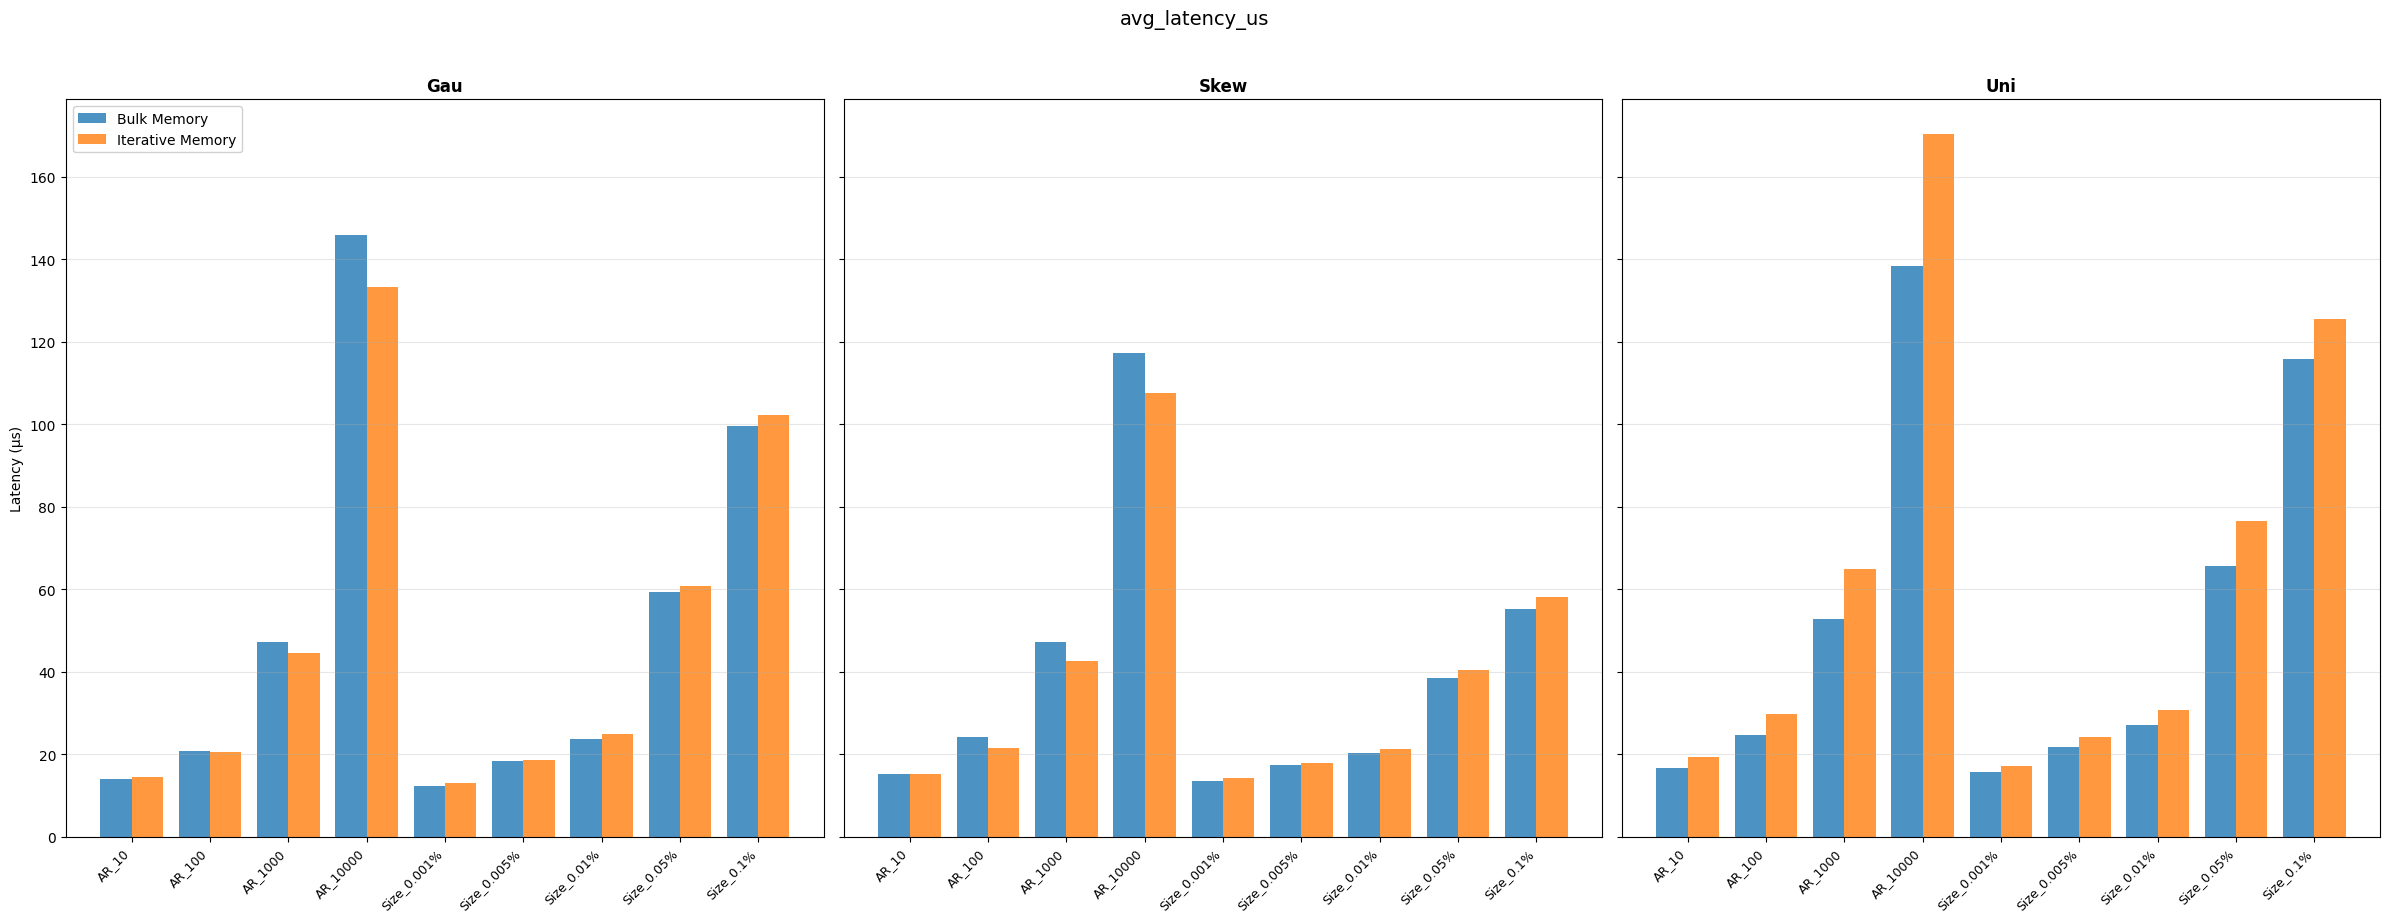

In [44]:
plot_comparison_multiplot(results_dict2, metric='avg_latency_us', figsize=(24, 9))

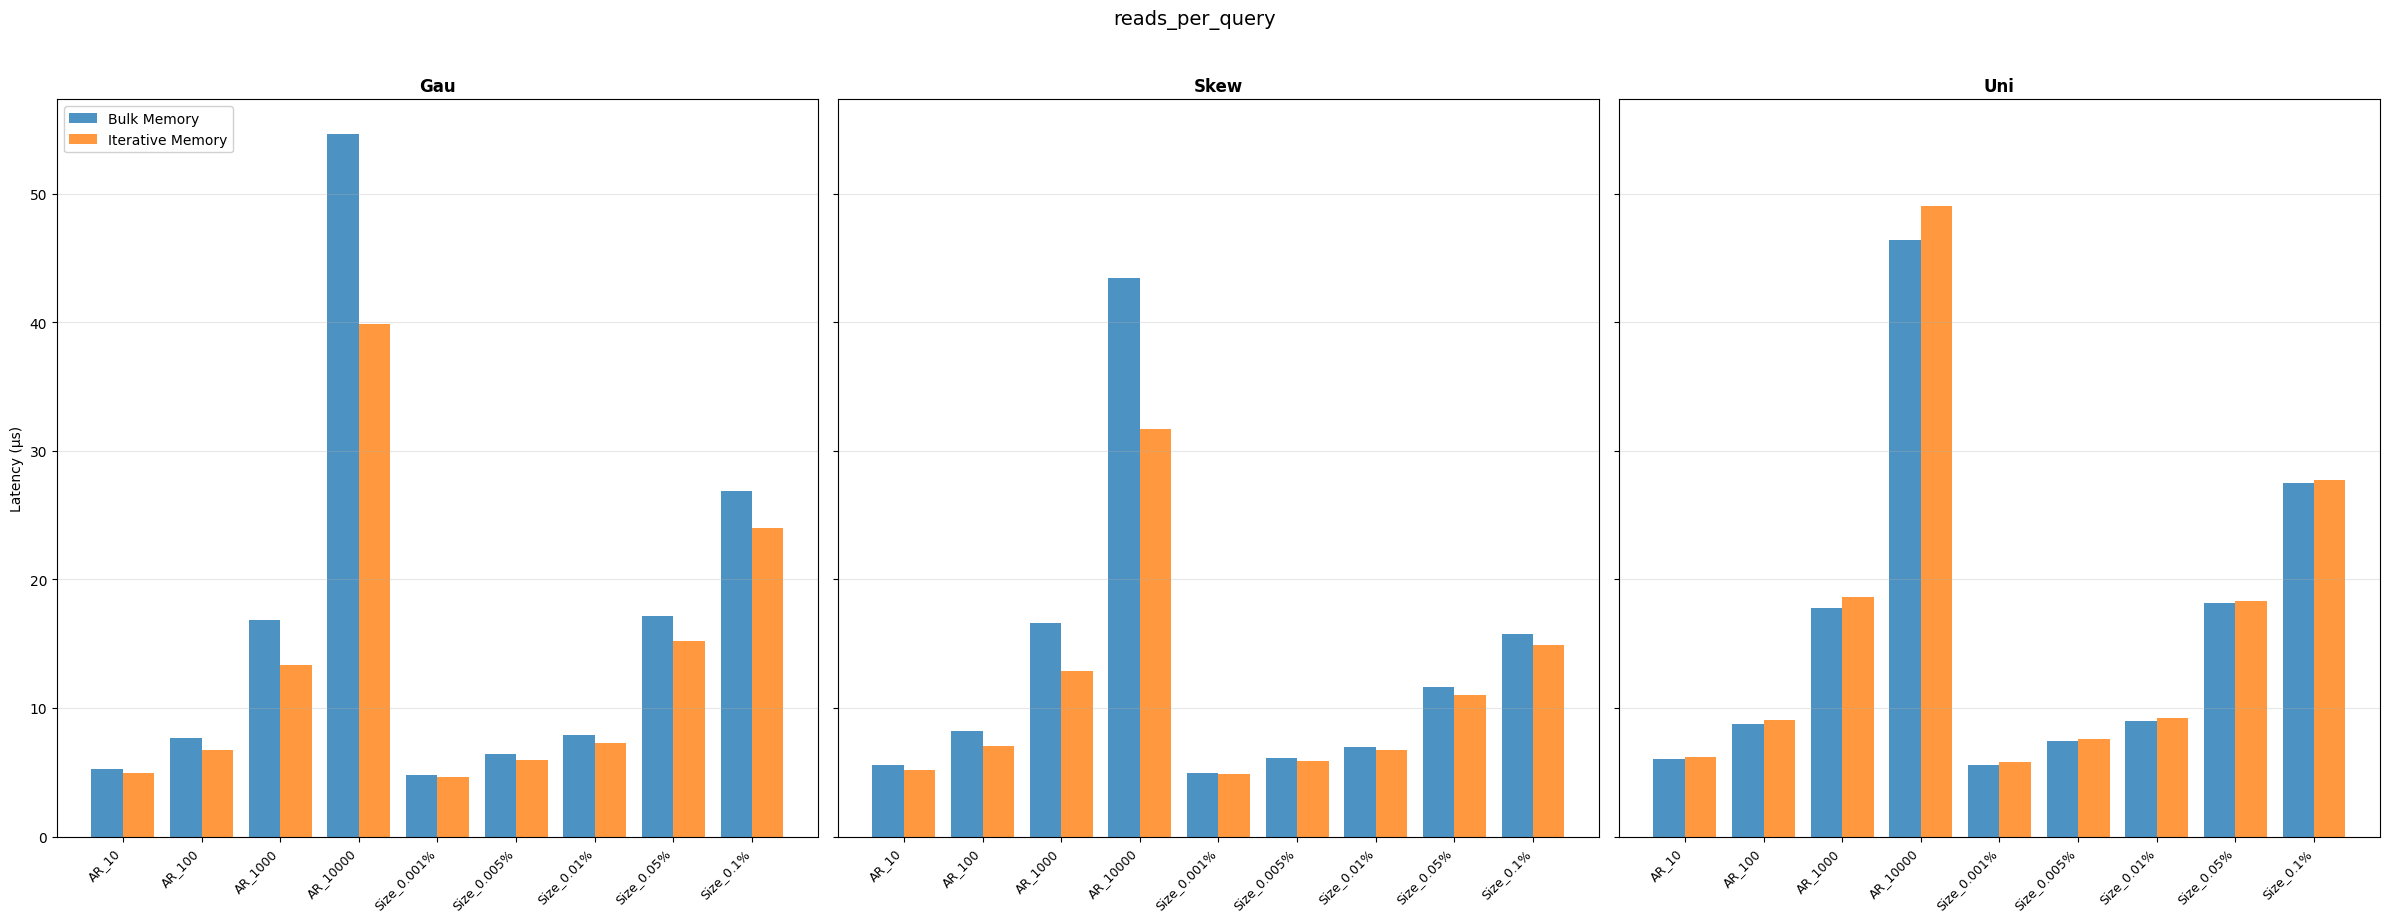

In [45]:
plot_comparison_multiplot(results_dict2, metric='reads_per_query', figsize=(24, 9))

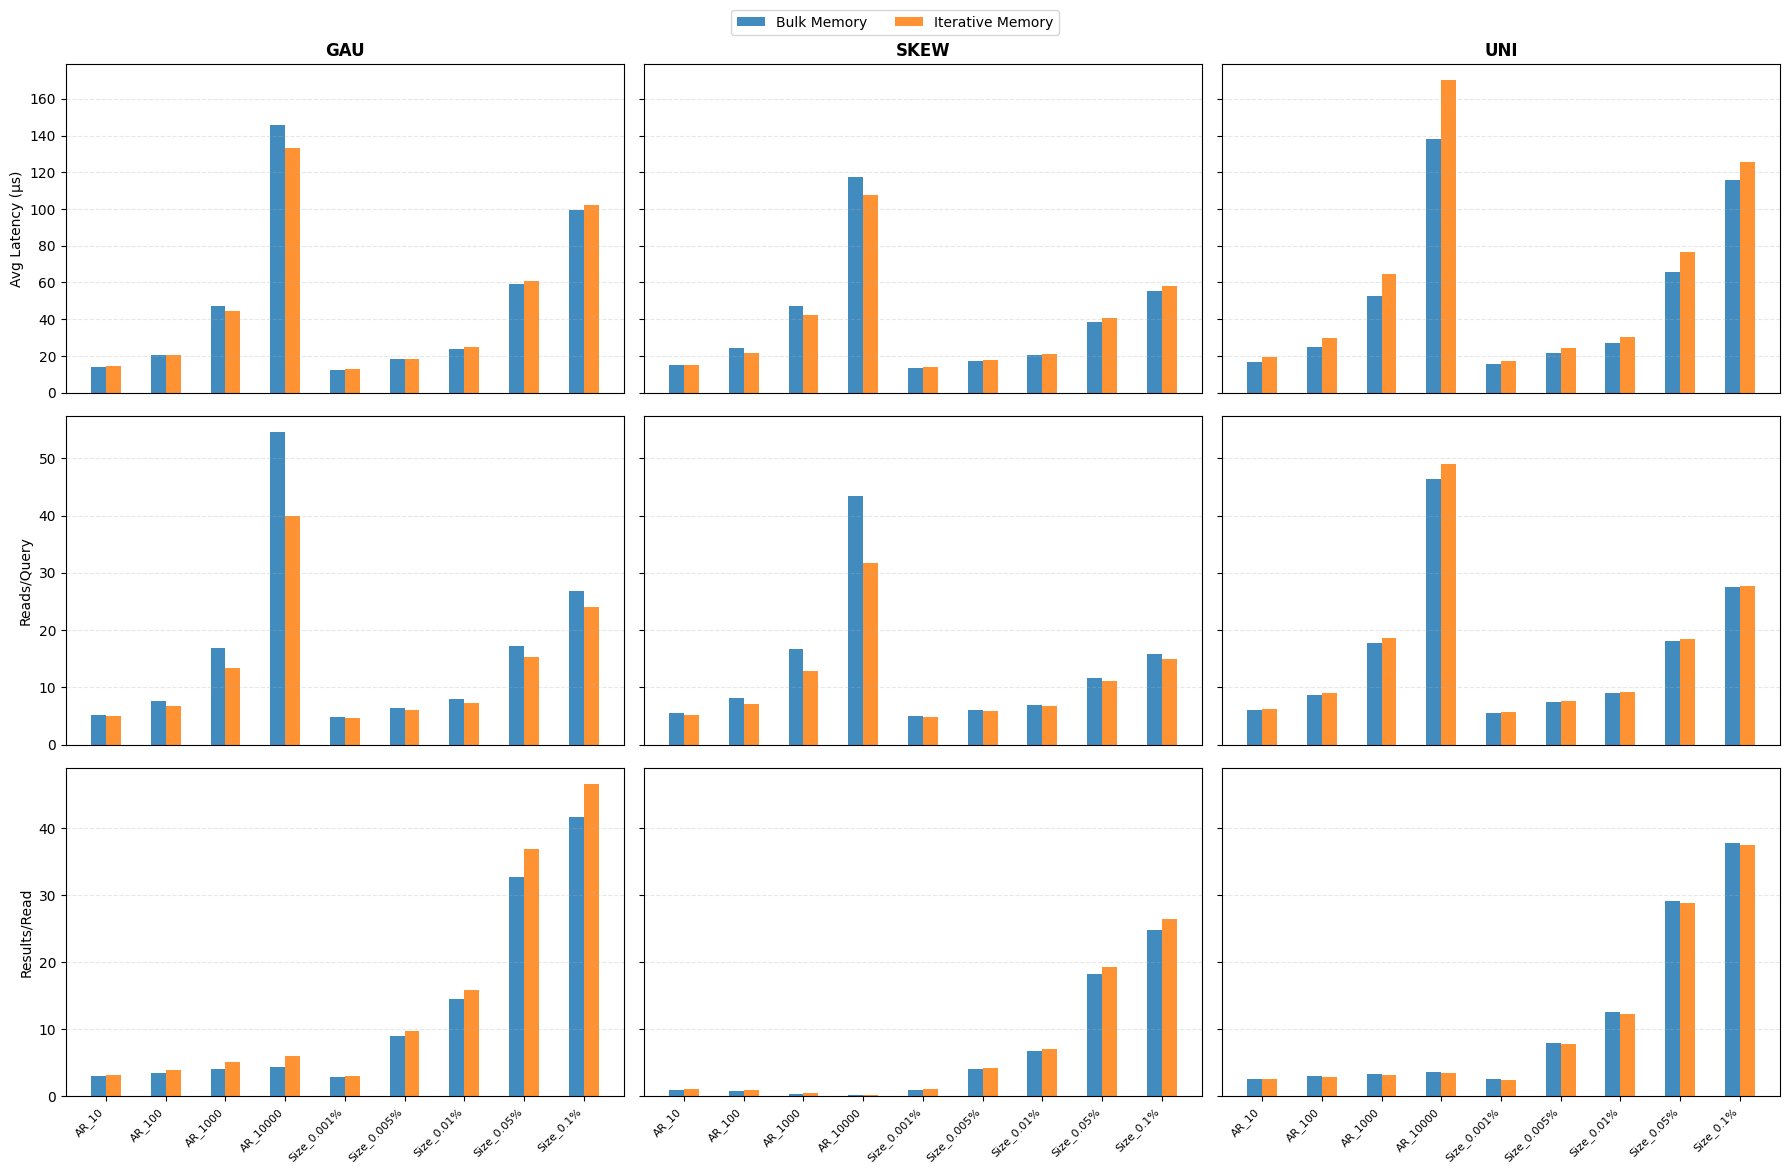

In [46]:
plot_comprehensive_comparison(results_dict2, metrics=['avg_latency_us', 'reads_per_query', 'results_per_read'])

In [47]:
results_mem_mult = {
    'Bulk Memory': summary_memory_multi[summary_memory_multi['dataset'].str.contains('bulk')],
    'Iterative Memory': summary_memory_multi[summary_memory_multi['dataset'].str.contains('iterative')],
}

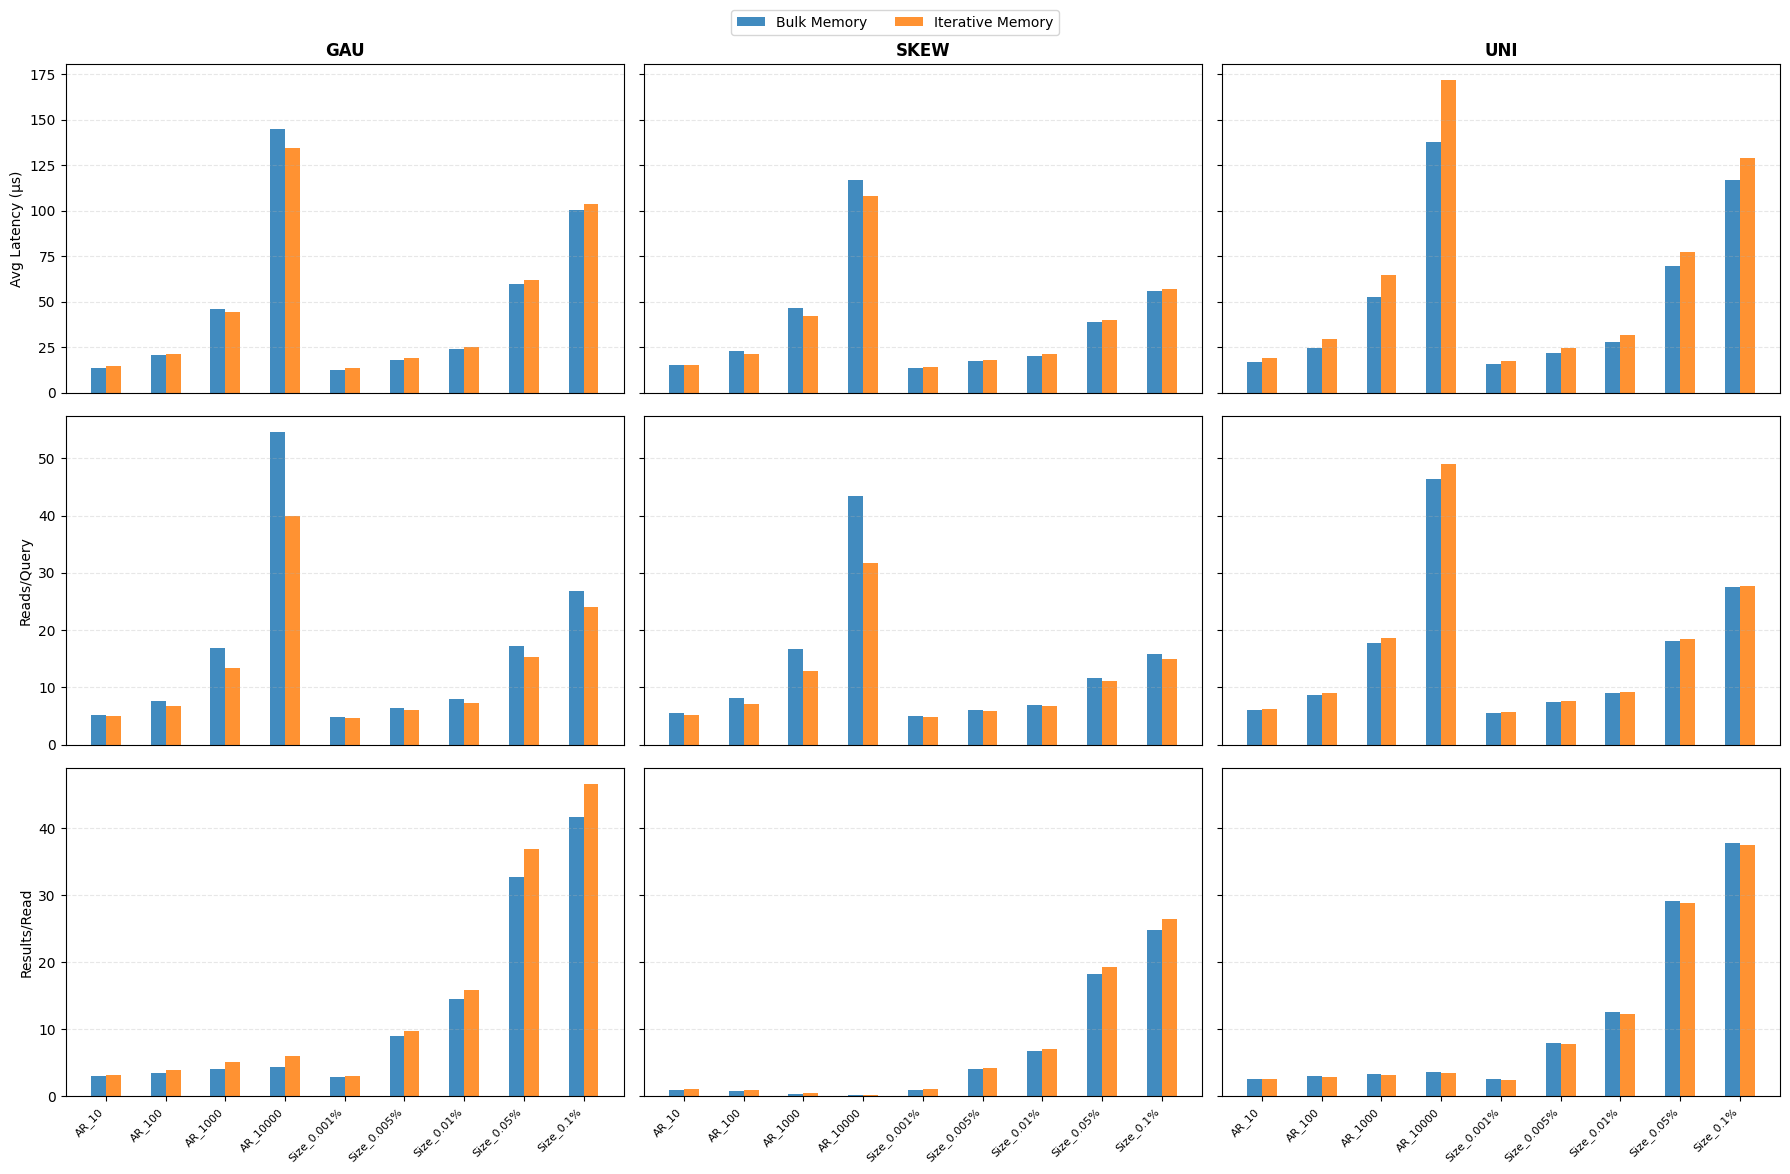

In [48]:
plot_comprehensive_comparison(results_mem_mult, metrics=['avg_latency_us', 'reads_per_query', 'results_per_read'])

### 5 HDBSCAN

https://hdbscan.readthedocs.io/en/latest/how_hdbscan_works.html

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

#### 5.1 Import

In [49]:
import hdbscan
import warnings
import seaborn as sns
from collections import defaultdict

warnings.filterwarnings("ignore")
plot_kwds = {'alpha' : 0.5, 's' : 80, 'linewidths':0}

#### 5.2 Function definitions

In [50]:
def extract_bounds(df):
    if {'x','y'}.issubset(df.columns):
        xs = df['x'].to_numpy()
        ys = df['y'].to_numpy()
        minx = xs
        miny = ys
        maxx = xs
        maxy = ys

    elif {'center_x','center_y','width','height'}.issubset(df.columns):
        cx = df['center_x'].to_numpy()
        cy = df['center_y'].to_numpy()
        hw = df['width'].to_numpy() / 2
        hh = df['height'].to_numpy() / 2

        minx = cx - hw
        miny = cy - hh
        maxx = cx + hw
        maxy = cy + hh

    else:
        raise ValueError("Unsupported schema")

    return minx, miny, maxx, maxy

In [51]:
def validate_clusters(df, clusters, leaf_capacity):
    """
    Validate that clusters meet all requirements for HDBSCAN bulk loading.
    
    Args:
        df: DataFrame with spatial data
        clusters: Dict mapping cluster_id to list/array of indices
        leaf_capacity: Maximum entries per leaf node
    """
    if not clusters:
        raise ValueError("No clusters produced.")
    
    total_points = len(df)
    
    if -1 in clusters:
        raise ValueError("Noise cluster (-1) present. All points must be assigned to valid clusters.")
    
    seen_ids = []
    for cid, idxs in clusters.items():
        idxs_array = np.asarray(idxs)
        
        size = len(idxs_array)
        if size == 0:
            raise ValueError(f"Cluster {cid} is empty.")
        
        if size > leaf_capacity:
            raise ValueError(
                f"Cluster {cid} size ({size}) exceeds leaf capacity ({leaf_capacity})."
            )
        
        if np.any(idxs_array >= total_points) or np.any(idxs_array < 0):
            raise ValueError(
                f"Cluster {cid} contains indices out of range [0, {total_points})."
            )
        
        seen_ids.append(idxs_array)
    
    if not seen_ids:
        raise ValueError("No valid clusters found.")
    
    all_ids = np.concatenate(seen_ids)
    
    if len(all_ids) != total_points:
        raise ValueError(
            f"Coverage mismatch: {len(all_ids)} points in clusters, but DataFrame has {total_points} points."
        )
    
    unique_ids = np.unique(all_ids)
    if len(unique_ids) != len(all_ids):
        duplicates = len(all_ids) - len(unique_ids)
        raise ValueError(
            f"Duplicate point assignment: {duplicates} points appear in multiple clusters."
        )
    
    # Check all points from 0 to n-1 are present
    expected_ids = np.arange(total_points)
    if not np.array_equal(np.sort(all_ids), expected_ids):
        missing = set(expected_ids) - set(all_ids)
        raise ValueError(
            f"Some point indices are missing from clusters: {sorted(list(missing))[:10]}"
        )

In [52]:
def prepare_clustered_data(df, cluster_labels, leaf_capacity):
    """
    Prepares clustered data with header records for the C++ bulkloader.
    
    Args:
        df: DataFrame with spatial data
        cluster_labels: np.array of cluster assignments
    
    Returns:
        generator: Yields (id, bounds, obj) tuples
        stats: Dictionary with cluster statistics
    """
    minx, miny, maxx, maxy = extract_bounds(df)
    
    clusters = defaultdict(list)
    for i, cid in enumerate(cluster_labels):
        clusters[cid].append(i)
    
    clusters = {cid: np.asarray(idxs) for cid, idxs in clusters.items()}

    validate_clusters(df, clusters, leaf_capacity)
    print("Cluster validation passed.")

    centroids = {}
    mbrs = {}
    for cid, idxs in clusters.items():
        cx = ((minx[idxs] + maxx[idxs]) * 0.5).mean()
        cy = ((miny[idxs] + maxy[idxs]) * 0.5).mean()
        centroids[cid] = (cx, cy)
        
        mbrs[cid] = (
            minx[idxs].min(),
            miny[idxs].min(),
            maxx[idxs].max(),
            maxy[idxs].max()
        )
    
    sorted_cids = sorted(clusters.keys(), key=lambda cid: centroids[cid])
    
    stats = {
        'total_points': len(df),
        'num_clusters': len(clusters),
        'cluster_sizes': [len(clusters[cid]) for cid in sorted_cids],
        'sorted_cluster_ids': sorted_cids,
        'cluster_info': {
            cid: {
                'size': len(clusters[cid]),
                'centroid': centroids[cid],
                'mbr': mbrs[cid]
            }
            for cid in sorted_cids
        }
    }
    
    def data_generator():
        for cid in sorted_cids:
            idxs = clusters[cid]
            size = len(idxs)
            
            # Yield header record
            yield (-size, (0, 0, 0, 0), None)
            
            # Yield actual points
            for i in idxs:
                yield (i, (minx[i], miny[i], maxx[i], maxy[i]), None)
    
    return data_generator(), stats

In [53]:
def print_cluster_statistics(stats):
    cluster_sizes = stats['cluster_sizes']
    
    print(f"Total points: {stats['total_points']}")
    print(f"Number of clusters: {stats['num_clusters']}")
    print(f"Cluster sizes: min={min(cluster_sizes)}, max={max(cluster_sizes)}, "
          f"mean={np.mean(cluster_sizes):.1f}")
    
    print(f"\nCluster order (first 10):")
    offset = 0
    for i, cid in enumerate(stats['sorted_cluster_ids'][:10]):
        size = stats['cluster_info'][cid]['size']
        print(f" Position {i} (cluster ID {cid}): records {offset} to {offset + size - 1} (size: {size})")
        offset += size
    
    print(f"\nSample cluster info (first 5):")
    for i, cid in enumerate(stats['sorted_cluster_ids'][:5]):
        info = stats['cluster_info'][cid]
        print(f"Position {i} (cluster ID {cid}):")
        print(f"  Size: {info['size']}")
        print(f"  Centroid: ({info['centroid'][0]:.4f}, {info['centroid'][1]:.4f})")
        print(f"  MBR: ({info['mbr'][0]:.4f}, {info['mbr'][1]:.4f}, "
              f"{info['mbr'][2]:.4f}, {info['mbr'][3]:.4f})")

In [54]:
def build_hdbscan_rtree(data_gen, path=None):    
    p = index.Property()
    p.dimension = 2
    p.pagesize = Page_Size
    p.leaf_capacity = Capacity
    p.index_capacity = Capacity
    p.fill_factor = fill_factor
    p.bulk_load_method = 1
    
    if path is None:
        p.storage = index.RT_Memory
        return index.Index(data_gen, properties=p)
    else:
        p.storage = index.RT_Disk
        return index.Index(path, data_gen, properties=p)

In [55]:
def build_hdbscan_with_stats(data_gen, path=None, label="hdbscan_tree"):
    t0 = time.perf_counter()
    idx = build_hdbscan_rtree(data_gen, path)
    t1 = time.perf_counter()
    
    s = idx.get_statistics()
    
    stats_data = {
        "dataset": label,
        "method": "hdbscan_bulk",
        "storage": "disk" if path else "memory",
        "build_time_s": t1 - t0,
        "reads": s['reads'],
        "writes": s['writes'],
        "nodes": s['nodes'],
        "splits": s['splits'],
        "adjustments": s['adjustments'],
        "height": s['tree_height'],
        "nodes_per_level": s['nodes_per_level']
    }
    
    return idx, stats_data

In [56]:
def create_all_rtrees_hdbscan(datasets, configs, data_gen):
    all_results = []
    active_trees = {}
    
    for name, df in datasets.items():
        for cfg in configs:
            path = f"{name}_{cfg['suffix']}" if cfg['disk'] else None
            
            # Check if disk tree already exists
            if cfg['disk'] and tree_exists(name, cfg['suffix']):
                
                idx = index.Index(path)
                s = idx.get_statistics()
                
                stats_data = {
                    "dataset": name,
                    "method": "iterative" if not cfg['bulk'] else ("hdbscan_bulk" if cfg['hdbscan'] else "str_bulk"),
                    "storage": "disk",
                    "build_time_s": None,  # Not tracked for existing disk trees
                    "reads": s['reads'],
                    "writes": s['writes'],
                    "nodes": s['nodes'],
                    "splits": s['splits'],
                    "adjustments": s['adjustments'],
                    "height": s['tree_height'],
                    "nodes_per_level": s['nodes_per_level']
                }
                
                stats_data['full_method'] = f"{stats_data['method']}_{stats_data['storage']}"
                all_results.append(stats_data)
                
                idx.close()
                continue
            
            if cfg['hdbscan']:
                idx, stats = build_hdbscan_with_stats(data_gen, path, label=name)
            else:
                idx, stats = build_rtree_with_stats(df_to_mbr_generator(df), path, cfg['bulk'], label=name)

            stats['full_method'] = f"{stats['method']}_{stats['storage']}"
            all_results.append(stats)
            
            if cfg['disk']:
                idx.close()  # Close disk trees
            else:
                active_trees[f"{name}_{cfg['suffix']}"] = idx  # Keep memory trees alive
    
    df_results = pd.DataFrame(all_results)

    return df_results, active_trees

#### 5.3 Test

In [57]:
def generate_test_cluster(num_clusters, points_per_cluster, compactness):
    grid_cols = int(np.ceil(np.sqrt(num_clusters)))
    grid_rows = int(np.ceil(num_clusters / grid_cols))

    spacing_x = 1 / grid_cols
    spacing_y = 1 / grid_rows

    cluster_std = min(spacing_x, spacing_y) * compactness

    points = []

    for cid in range(num_clusters):
        row = cid // grid_cols
        col = cid % grid_cols

        cx = (col + 0.5) * spacing_x
        cy = (row + 0.5) * spacing_y

        xs = np.random.normal(cx, cluster_std, points_per_cluster)
        ys = np.random.normal(cy, cluster_std, points_per_cluster)

        for x, y in zip(xs, ys):
            points.append({"x": x, "y": y, "true_cluster": cid})

    return pd.DataFrame(points)

In [58]:
def plot_test_clusters(df):
    _, ax = plt.subplots(figsize=(12, 10))

    ax.scatter(
        df["x"],
        df["y"],
        c=df["true_cluster"],
        s=8,
        alpha=0.7
    )

    ax.set_title("Test Clusters", fontsize=14, fontweight='bold')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")

    plt.show()

In [59]:
def plot_hdbscan_clusters(df, labels, probabilities, plot_kws, x_col, y_col, figsize):    
    _, ax = plt.subplots(figsize=figsize)
    
    n_clusters_found = labels.max() + 1
    palette_size = max(1, n_clusters_found)

    palette = sns.color_palette('deep', palette_size)
    
    cluster_colors = [sns.desaturate(palette[col], sat)
                      if col >= 0 else (0.5, 0.5, 0.5) 
                      for col, sat in zip(labels, probabilities)]
    
    ax.scatter(df[x_col], df[y_col], c=cluster_colors, **plot_kws)
    
    ax.set_xlabel(x_col.replace('_', ' ').title())
    ax.set_ylabel(y_col.replace('_', ' ').title())
    ax.set_title(f'HDBSCAN found {n_clusters_found} clusters (and noise)')
    
    plt.show()

In [60]:
test = generate_test_cluster(num_clusters=8690, points_per_cluster=79, compactness=0.07)

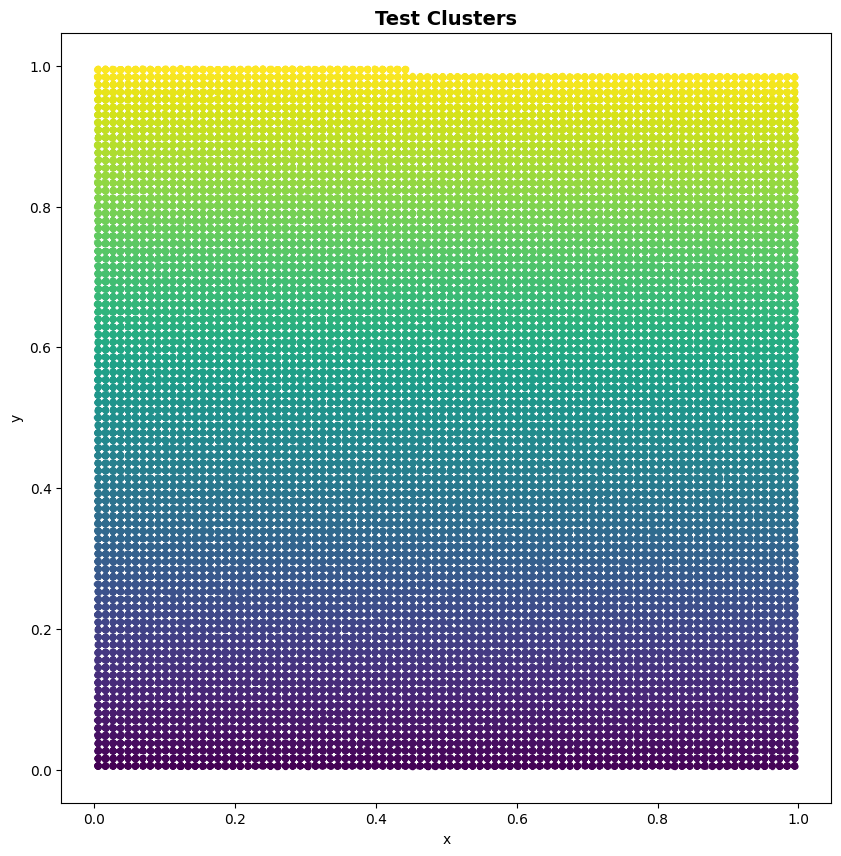

In [61]:
plot_test_clusters(test)

In [62]:
clusterer = hdbscan.HDBSCAN(algorithm='best', alpha=1.0, approx_min_span_tree=True, allow_single_cluster = False, cluster_selection_epsilon = 0.5, cluster_selection_method = 'eom',
    gen_min_span_tree=True, leaf_size=40, metric='euclidean', min_cluster_size=70, min_samples=5,  p=None)
clusterer.fit(test)

,min_cluster_size,70
,min_samples,5
,cluster_selection_epsilon,0.5
,cluster_selection_persistence,0.0
,max_cluster_size,0
,metric,'euclidean'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


In [63]:
noise_count = (clusterer.labels_ == -1).sum()
print(f"Number of noise points: {noise_count}")

Number of noise points: 0


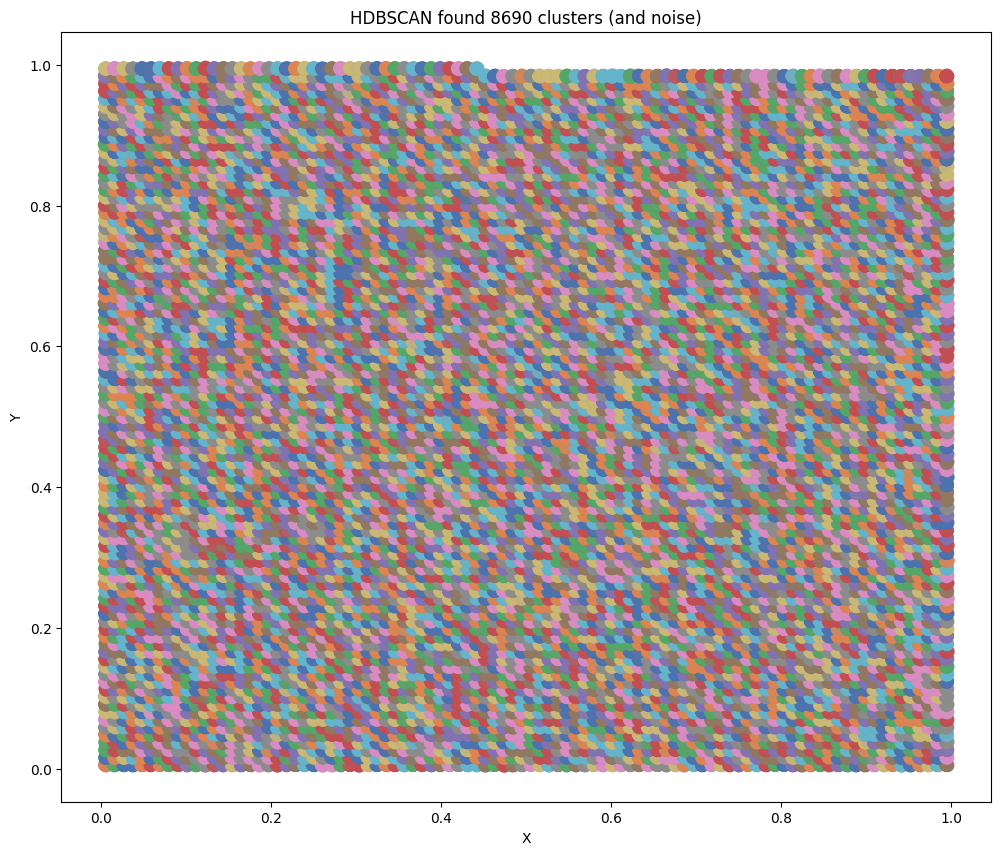

In [64]:
plot_hdbscan_clusters(test, clusterer.labels_, clusterer.probabilities_, plot_kwds, x_col='x', y_col='y', figsize=(12, 10))

In [65]:
data_gen, cluster_stats = prepare_clustered_data(test, clusterer.labels_, leaf_capacity=Capacity)

Cluster validation passed.


In [66]:
test_dataset = {
    "TEST": test
}

In [67]:
test_config = [
    {"bulk": True, "hdbscan": True, "disk": False, "suffix": "hdbscan_bulk_memory"},
    {"bulk": True, "hdbscan": False, "disk": False, "suffix": "str_bulk_memory"},
    {"bulk": False, "hdbscan": False, "disk": False, "suffix": "iterative_memory"},
]

In [68]:
test_tree_stats, active_test_trees = create_all_rtrees_hdbscan(test_dataset, test_config, data_gen)

In [69]:
test_tree_stats

,dataset,method,storage,build_time_s,reads,writes,nodes,splits,adjustments,height,nodes_per_level,full_method
0,TEST,hdbscan_bulk,memory,1.475217,1,8804,8803,0,0,4,"[8690, 110, 2, 1]",hdbscan_bulk_memory
1,TEST,str_bulk,memory,12.128721,1,8804,8803,0,0,4,"[8690, 110, 2, 1]",str_bulk_memory
2,TEST,iterative,memory,37.349907,4647738,2138711,9488,9485,859749,3,"[9383, 104, 1]",iterative_memory


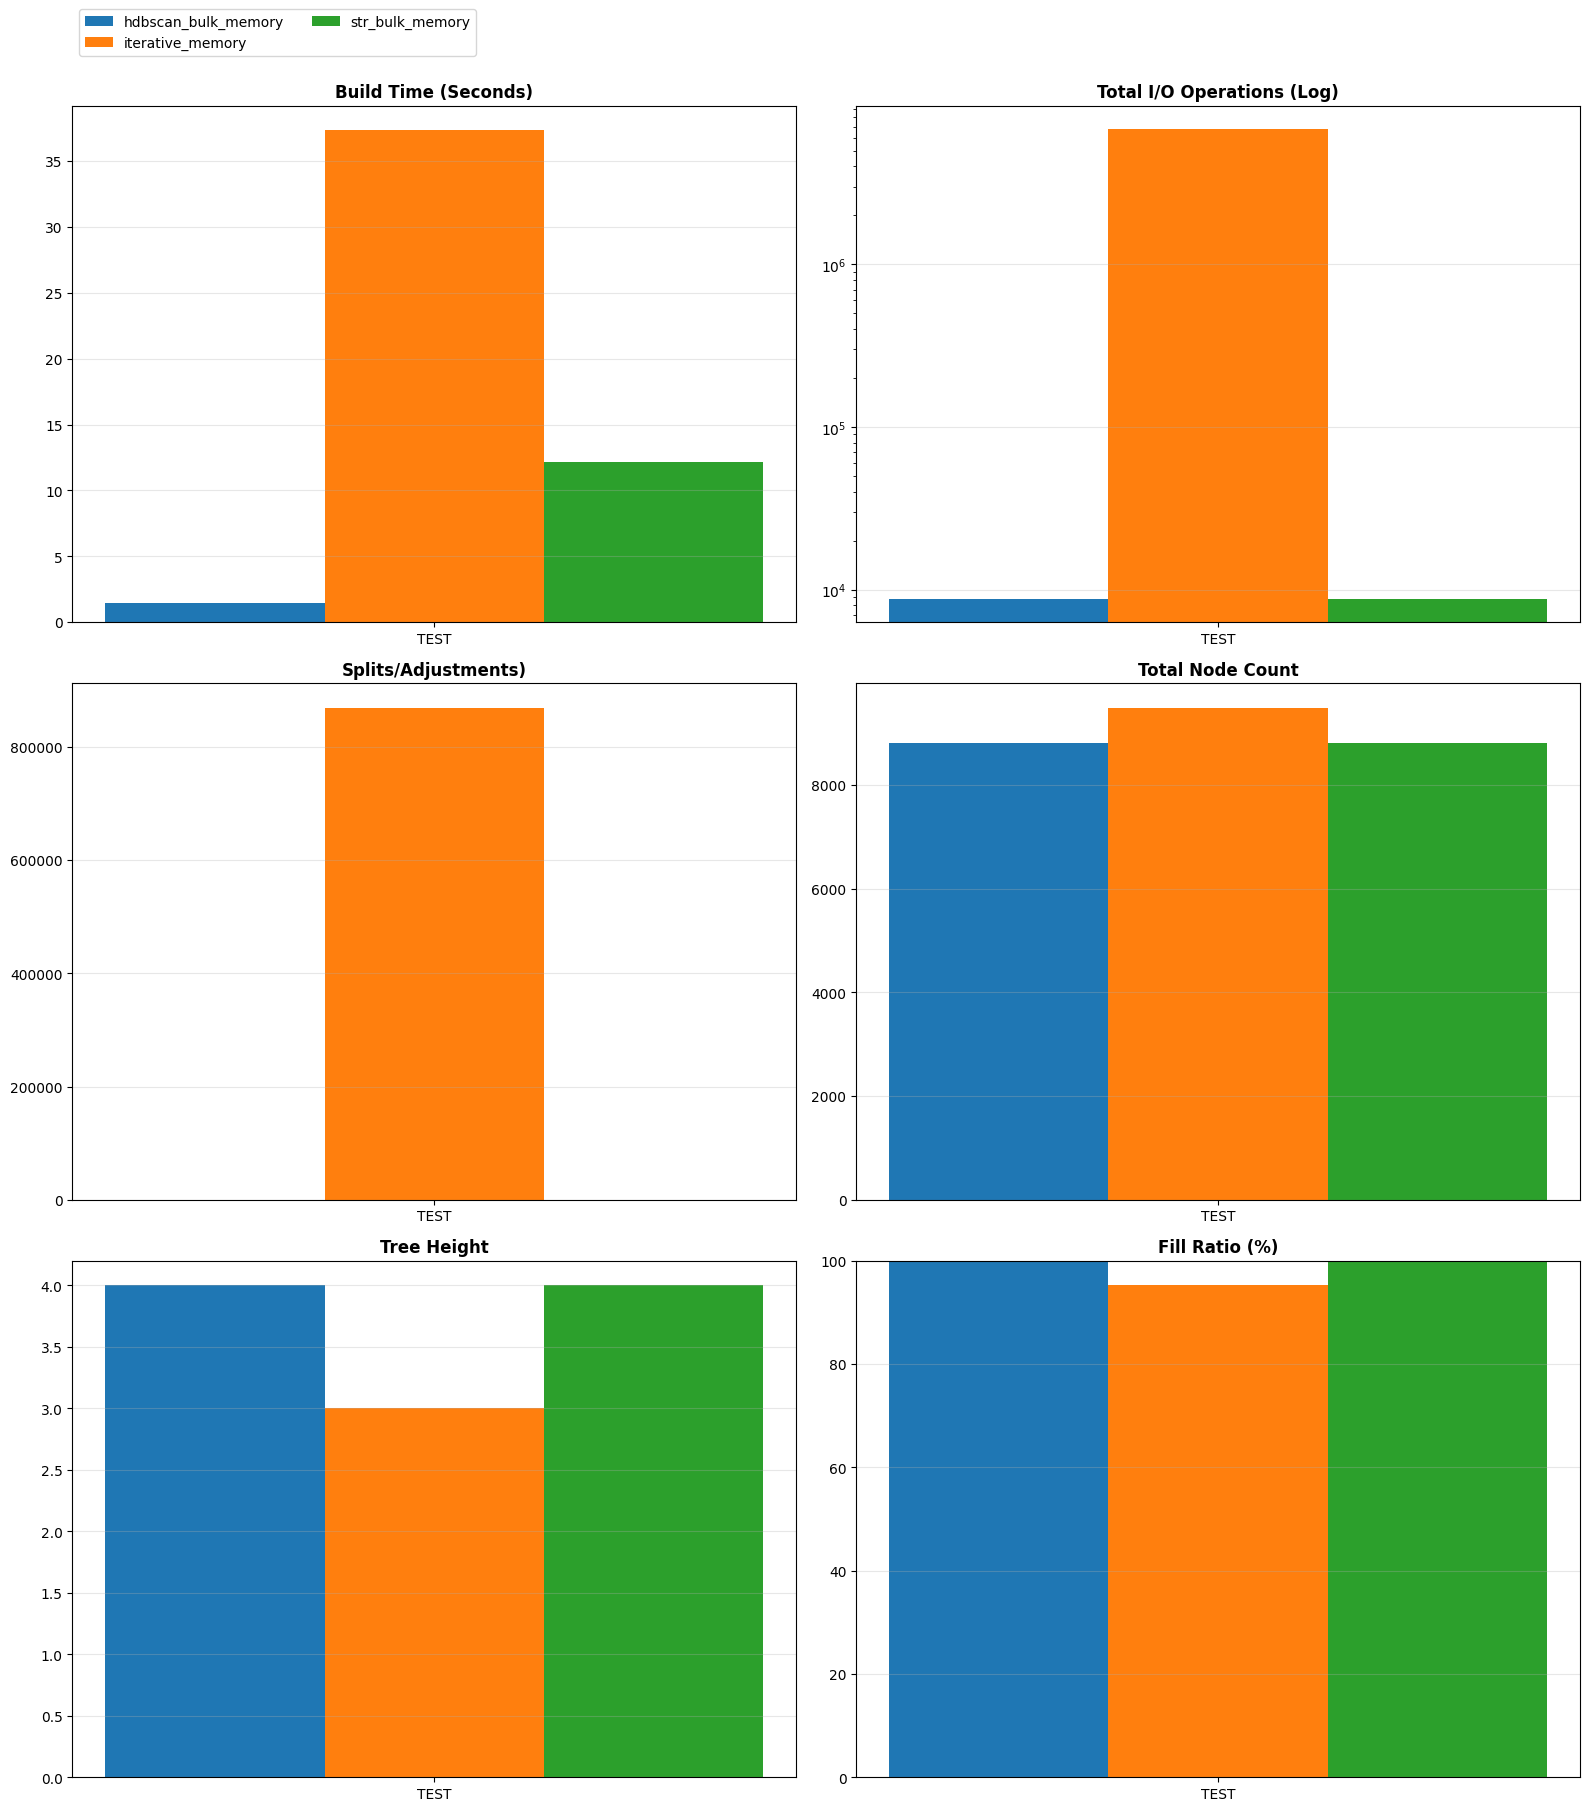

In [70]:
plot_rtree_build_analysis(test_tree_stats, 8960*79)

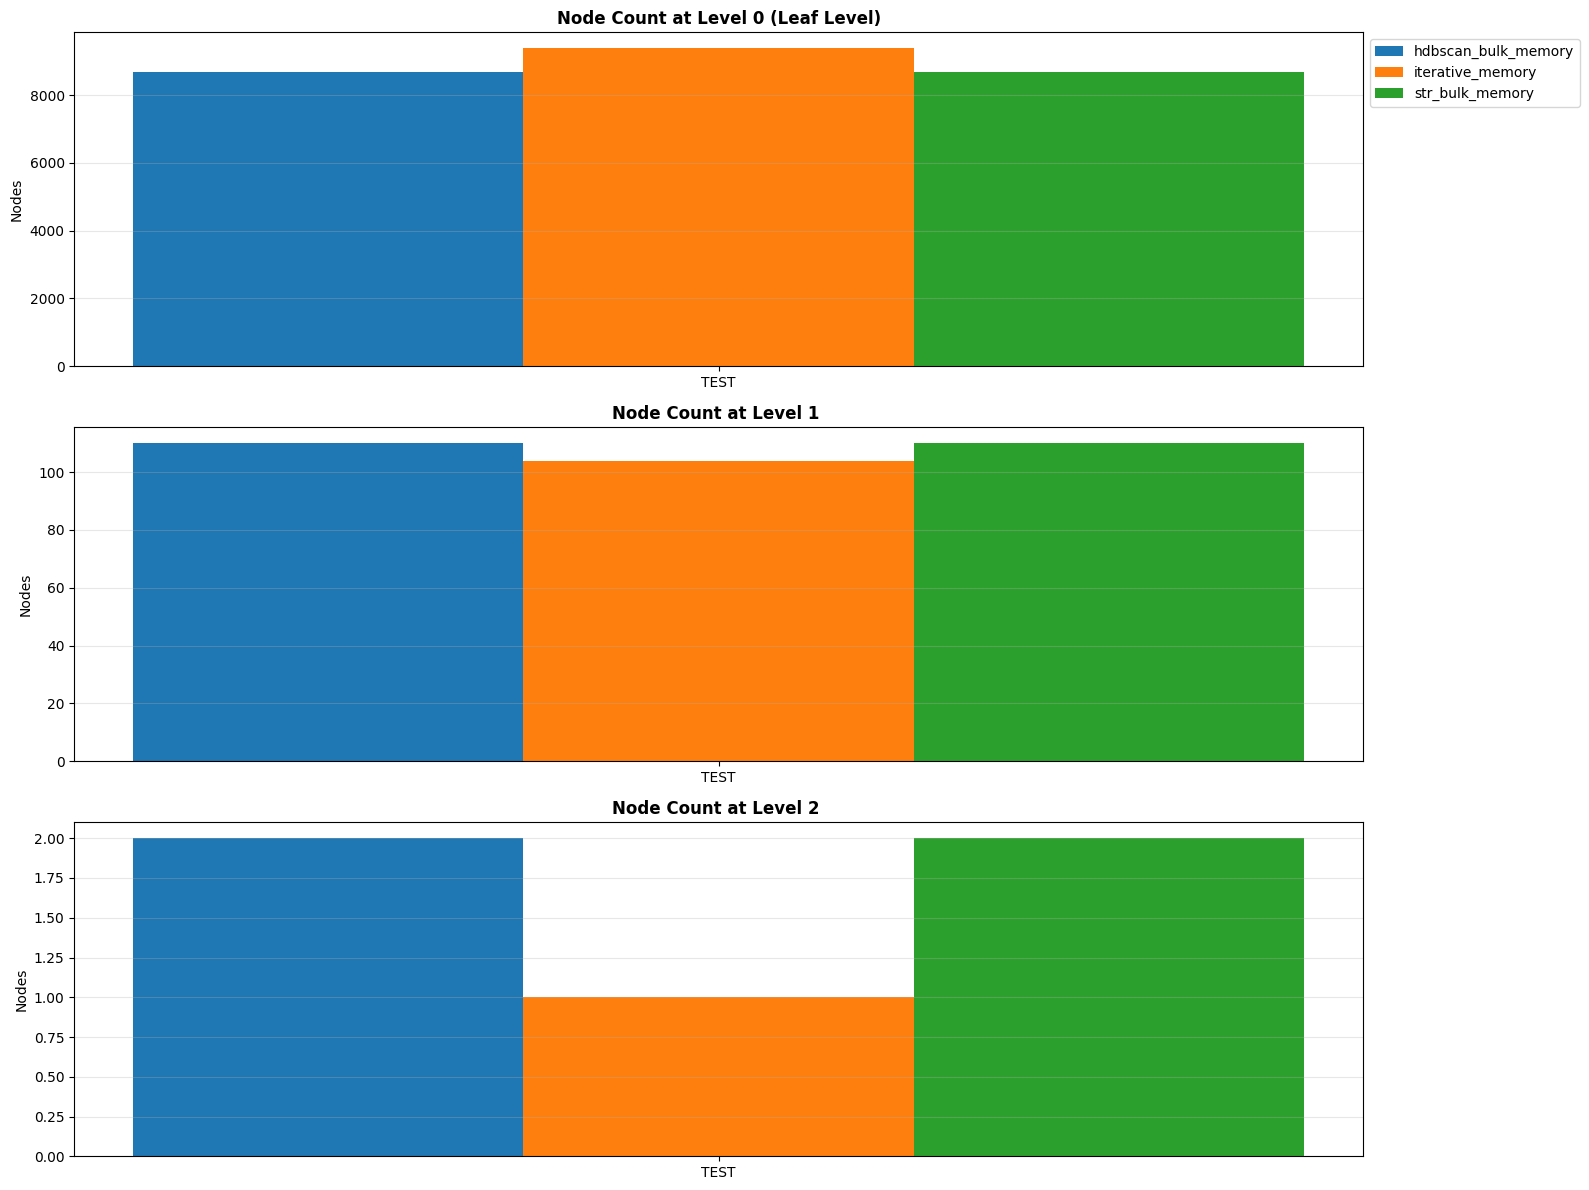

In [71]:
plot_nodes_per_level(test_tree_stats)

In [72]:
test_result_df, test_stats_df = benching(active_test_trees, workloads)

In [73]:
summary_test = summarize_benchmark_single(test_result_df, test_stats_df, precision=4)
summary_test

,dataset,workload,avg_latency_us,p50_latency_us,p95_latency_us,p99_latency_us,min_latency_us,max_latency_us,query_results,reads,reads_per_query,results_per_read
0,TEST_hdbscan_bulk_memory,AR_10,9.7717,9.1810,15.3011,19.4314,2.910,93.574,68265,37703,3.77,1.81
1,TEST_hdbscan_bulk_memory,AR_100,12.1346,10.1300,20.9810,25.8012,2.940,90.244,69127,46348,4.63,1.49
2,TEST_hdbscan_bulk_memory,AR_1000,20.1383,12.1855,41.1810,50.3523,3.020,112.105,68904,74964,7.50,0.92
3,TEST_hdbscan_bulk_memory,AR_10000,42.4286,18.6800,99.5555,109.6952,3.040,216.420,69362,164773,16.48,0.42
4,TEST_hdbscan_bulk_memory,Size_0.001%,9.6141,9.2700,14.6915,19.8416,2.920,72.373,71862,36687,3.67,1.96
5,TEST_hdbscan_bulk_memory,Size_0.005%,12.6849,11.7910,21.5730,27.6313,3.180,52.353,342360,44183,4.42,7.75
6,TEST_hdbscan_bulk_memory,Size_0.01%,14.0392,13.9610,20.1715,24.8010,4.100,48.882,683692,51644,5.16,13.24
7,TEST_hdbscan_bulk_memory,Size_0.05%,30.8335,30.0210,42.5020,49.2525,4.551,84.524,3438482,99999,10.00,34.39
8,TEST_hdbscan_bulk_memory,Size_0.1%,54.2083,53.1530,75.0645,86.4546,5.290,161.168,6910240,153415,15.34,45.04
9,TEST_iterative_memory,AR_10,12.3228,11.5800,22.6515,27.3325,4.520,90.214,68265,33014,3.30,2.07


In [74]:
test_results_dict = {
    'STR': summary_test[summary_test['dataset'].str.contains('str_bulk')],
    'Iterative': summary_test[summary_test['dataset'].str.contains('iterative')],
    'HDBSCAN': summary_test[summary_test['dataset'].str.contains('hdbscan_bulk')],
}

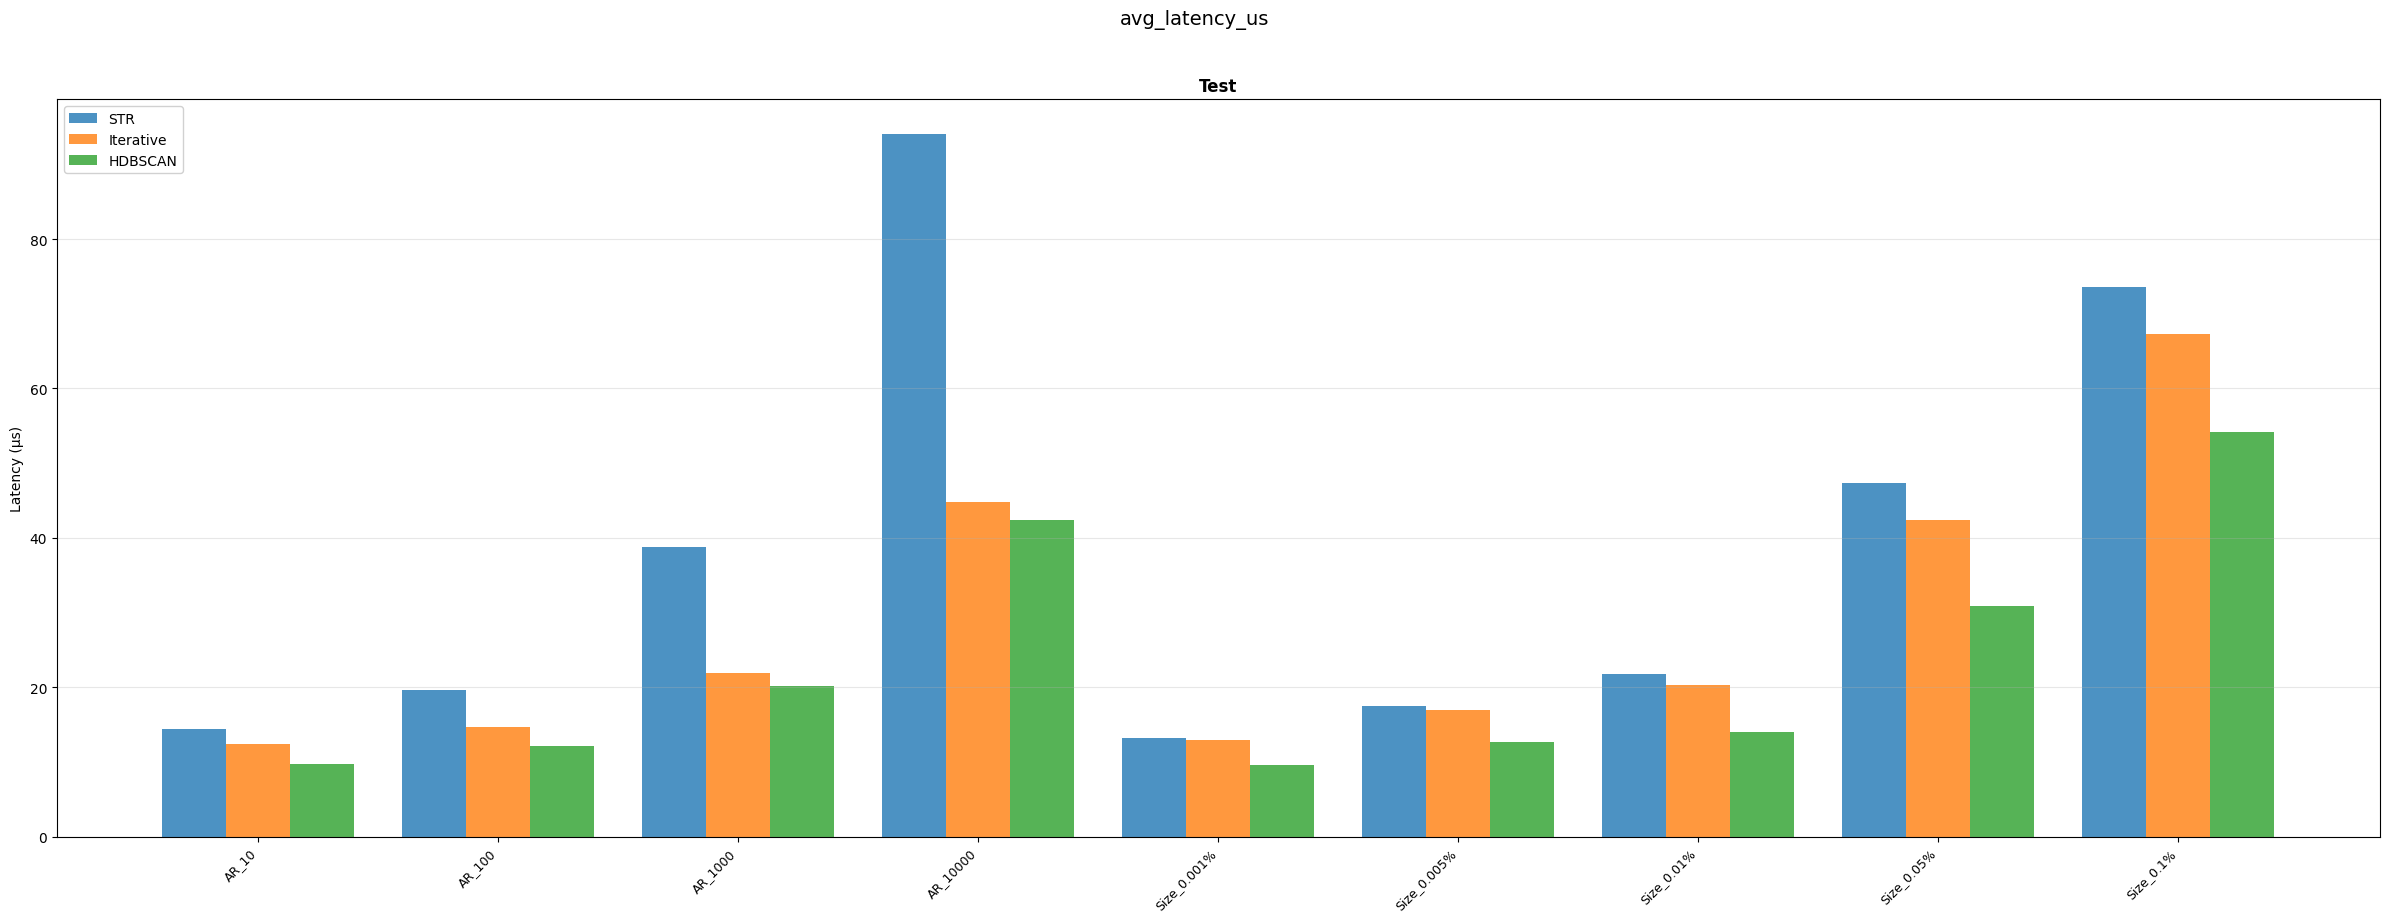

In [75]:
plot_comparison_multiplot(test_results_dict, metric='avg_latency_us', figsize=(24, 9))

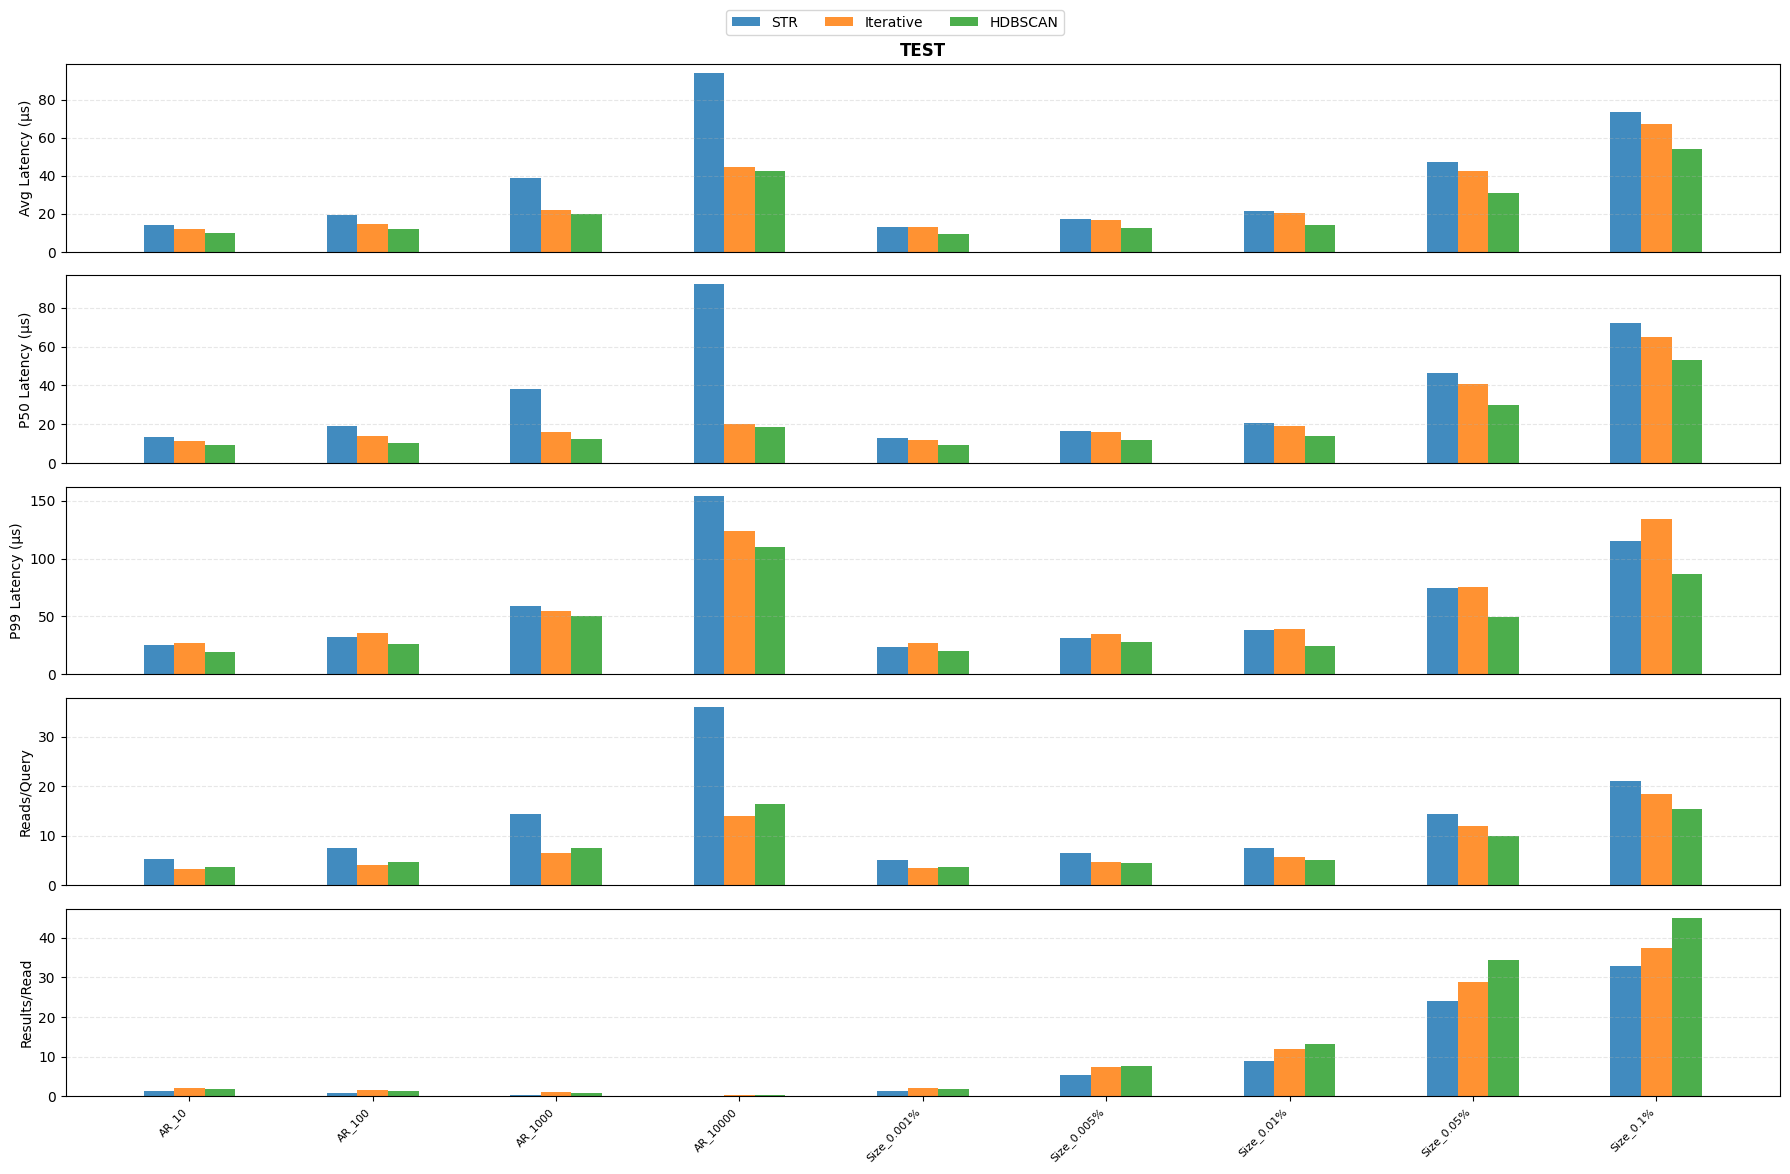

In [76]:
plot_comprehensive_comparison(test_results_dict,metrics=['avg_latency_us', 'p50_latency_us', 'p99_latency_us', 'reads_per_query', 'results_per_read'])

In [77]:
test_result_multi, test_stats_multi = benching_multi_run(active_test_trees, workloads, 10)

In [78]:
summary_test_mult = summarize_benchmark_multi(test_result_multi, test_stats_multi, method='mean')
summary_test_mult

,dataset,workload,avg_latency_us,p50_latency_us,p95_latency_us,p99_latency_us,min_latency_us,max_latency_us,query_results,reads,reads_per_query,results_per_read
0,TEST_hdbscan_bulk_memory,AR_10,9.9431,9.261,15.3210,19.7710,2.910,755.683,68265,37703,3.77,1.81
1,TEST_hdbscan_bulk_memory,AR_100,12.3872,10.240,21.4410,27.5921,2.901,152.836,69127,46348,4.63,1.49
2,TEST_hdbscan_bulk_memory,AR_1000,20.1122,11.940,41.2520,48.5320,2.920,293.613,68904,74964,7.50,0.92
3,TEST_hdbscan_bulk_memory,AR_10000,43.6821,19.431,102.8855,116.9250,2.900,278.042,69362,164773,16.48,0.42
4,TEST_hdbscan_bulk_memory,Size_0.001%,9.3568,8.991,13.6510,17.8610,2.950,92.584,71862,36687,3.67,1.96
5,TEST_hdbscan_bulk_memory,Size_0.005%,12.0921,11.470,18.1710,24.2110,2.950,170.298,342360,44183,4.42,7.75
6,TEST_hdbscan_bulk_memory,Size_0.01%,14.4700,14.160,21.1700,27.3310,3.861,160.568,683692,51644,5.16,13.24
7,TEST_hdbscan_bulk_memory,Size_0.05%,33.0675,31.971,46.3820,56.1930,4.270,191.658,3438482,99999,10.00,34.39
8,TEST_hdbscan_bulk_memory,Size_0.1%,55.0313,53.553,77.2145,94.7542,5.050,276.512,6910240,153415,15.34,45.04
9,TEST_iterative_memory,AR_10,12.8718,11.980,23.7415,29.4711,4.380,123.325,68265,33014,3.30,2.07


In [79]:
test_mult_dict = {
    'STR': summary_test_mult[summary_test_mult['dataset'].str.contains('str_bulk')],
    'Iterative': summary_test_mult[summary_test_mult['dataset'].str.contains('iterative')],
    'HDBSCAN': summary_test_mult[summary_test_mult['dataset'].str.contains('hdbscan_bulk')],
}

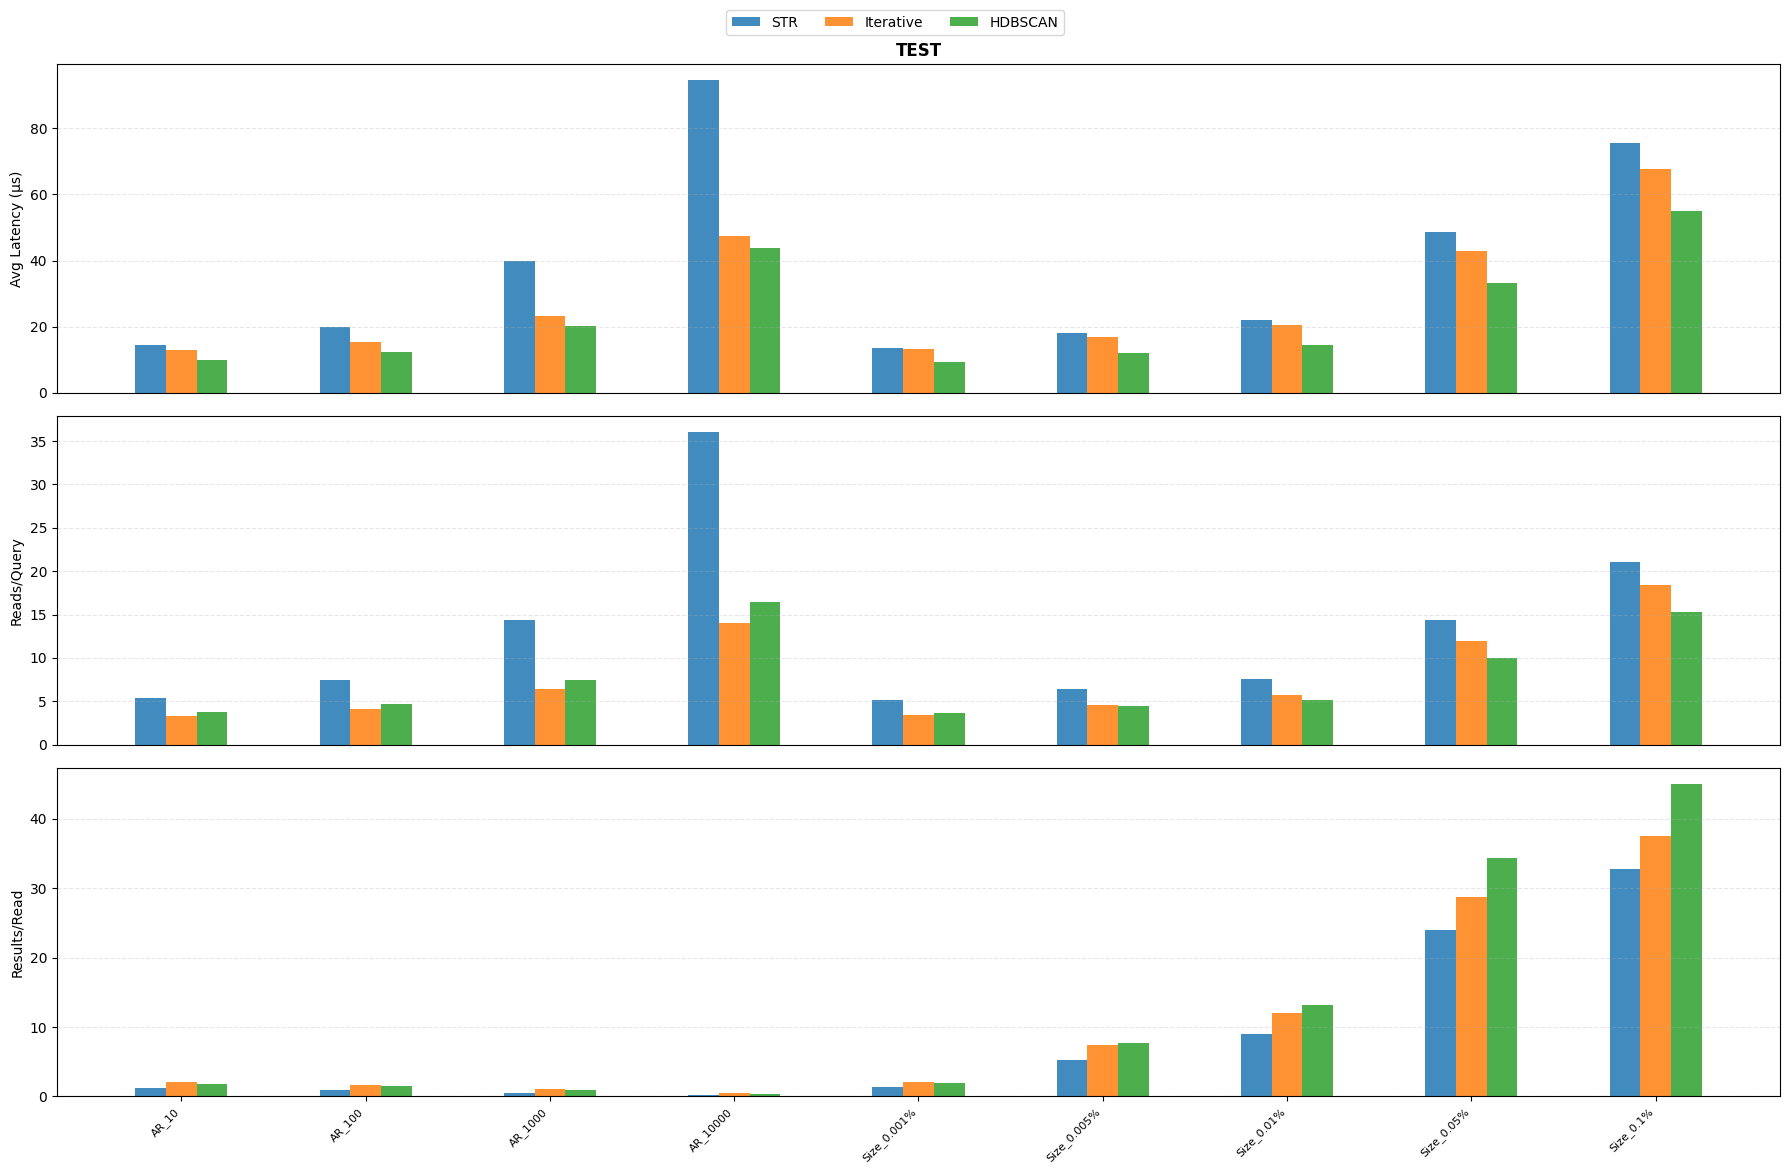

In [80]:
plot_comprehensive_comparison(test_mult_dict,metrics=['avg_latency_us', 'reads_per_query', 'results_per_read'])

#### Further Tests

Challenges:
1) How to treat noise points
2) How to treat Clusters that are bigger than the leaf capacity (or in this case the "effective capacity" = fill_factor * Capacity)
3) How to set the HDBSCAN parameters in the initial run
4) Should a min_points per cluster be enforced


1:
Given that all points have to be inserted into the tree noise points have to be handled in some way. Putting them all into a new cluster (which likely would have more than lead capacity points which would need to be handled) is probelematic as the noise points can be almost anywhere which could lead to leaf pages that span quite a bit of area with a lot of dead space as well as potentially a lot of overlap with other pages.In a worst case scenario it mcould create a leaf page the size of the root page.

After the initial run assign noise points, if they exist, to the initially found clusters. How to assign? 1. Based on which leaf page gains the lowest amount of additional space. 2. Based on which cluster is closest by a given metric (closest to what excactly? The centroid of the MBR? The closest point on the edge of the MBR?) 

Should all noise points be assigned to one of the found clusters? Or only those within a certain distance from all found clusters? The remaining ones could be put in their own clusters (would need to ensure that the resulting MBRs do not cover to much space, perhaps possible to constrain them like only noise points located in the same quadrant (or smaller) can get assigned to a noise cluster). How would this interact with a potential min_points per cluster?

This could (or will) lead to clusters exceeding the leaf capacity if they did not do so before. If HDBSCAN gets called resusively this would have to be repeated every time noise points exist.

2: 
If a cluster has more than the specified leaf capacity of points the cluster needs to be split as the bulkloader assumes that the given clusters have at max leaf capacity points. What possible ways are there? 
Run HDBSCAN again with other parameter settings on these found clusters (which already have eventually existing noise points assigned to them) in the hope that this finds smaller clusters? Effectiveness of this likely very dependant on the dataset, if the data is a mostly homogeneous blob it will probably find a single big cluster again. 

Use a partioning algorithm that returns a number of smaller sections? How to determine how many partitions to create? Number of points, something else?

A general x way split where x depends on the amount of points that splits the clusters into areas of the same size? Could be made depending on how wide (x-axis) or high (y-axis) the MBR of the cluster is?

3: 
For the initial HDBSCAN run how should the parameters be set? Important attributes: min_cluster_size, min_samples, cluster_selection_epsilon. What about cluster_selection_method? By default uses Excess of mass which has a tendency to pick one or two bigger clusters. Alternative would be leaf which can produce many small homogeneous clusters offering a potentially more fine grained clustering.

Should min_cluster_size be set close to or at the capacity? Or something closer to 0.5 * capacity to allow for some smaller clusters to form? This could also allow for room to assign noise points without exceeding the capacity.

Should the aim be to generate more "liberal" clusters that may be bigger that then can be refined further? Or more "conservative" with more noise points?

Do we decide this based on the nature of the data, like how many points there are, how dense or spread out they are? How could this efficiently be determinded (would a rough approximation suffice?) for distribution that we do not know well? Or should we operate on the assumption that we have a good understanding of the data and always set these manually? (Probably not)